# Paper-Based Benchmark CNNs — UNSW-NB15, then Test on Synthetic IPv6

## Goal
This notebook builds **benchmark CNN methods from prior research papers**, before moving to our own CNN design.

It does three things:

1. **Train paper-based CNN benchmarks on UNSW-NB15**
2. **Evaluate them on the official UNSW test split**
3. **Test the trained benchmark CNNs on the synthetic IPv6 dataset** to measure transfer drop and identify where performance changes

## Important scope note
These are **three implemented benchmark methods**, but they come from **two source papers**:
- **Systems 2024 paper** gives two benchmark CNN architectures
- **Noever and Noever 2021** gives the image-based MobileNetV2 method

The synthetic dataset is **not used to fit these benchmark CNNs in this notebook**.  
It is used as the **external project-specific evaluation layer** after the models are trained on UNSW-NB15.

## Benchmark CNN methods included

### Method 1 — `systems2024_arch1_1dcnn`
From **Mohammad et al. (Systems, 2024), CNN Architecture 1**:
- `Conv1D -> MaxPool1D -> Conv1D -> MaxPool1D -> Flatten -> Dense(64) -> Dropout -> Output`
- The paper reports about **95% binary accuracy** and **82% multiclass accuracy** on UNSW-NB15 before augmentation.

**Paper URL:**  
https://www.mdpi.com/2079-8954/12/3/79

### Method 2 — `systems2024_arch2_1dcnn`
From the same paper, **CNN Architecture 2**:
- `Conv1D -> MaxPool1D -> Conv1D -> MaxPool1D -> Flatten -> Dense(128) -> Dropout -> Dense(64) -> Dropout -> Output`
- The paper presents this as a deeper benchmark architecture, but also reports that the simple CNN Architecture 1 was stronger on UNSW-NB15.

**Paper URL:**  
https://www.mdpi.com/2079-8954/12/3/79

### Method 3 — `noever2021_mobilenetv2_image`
From **Noever and Noever (2021)**:
- one-hot encode categoricals
- scale numeric features to grayscale values
- pad to a **16×16 grayscale thumbnail**
- train **MobileNetV2**
- the paper reports about **97% binary accuracy** and **56% 10-class accuracy** on UNSW-NB15

**Paper URL:**  
https://arxiv.org/abs/2103.07765

## Why this notebook comes before our own CNN
This is the benchmark layer.  
We first compare ourselves against methods that already exist in the literature.  
After that, we can build our own CNN ideas with a fair reference point.

## UNSW dataset reference
Official UNSW-NB15 dataset page:  
https://research.unsw.edu.au/projects/unsw-nb15-dataset

In [ ]:
# ============================================================
# 0) Setup
# ============================================================


import json
import random
import zipfile
from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
)

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch.nn.functional as F
from torchvision import models

GLOBAL_SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(GLOBAL_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

OUT_ROOT = Path("cnn_benchmark_artifacts")
for base in [OUT_ROOT / "unsw" / "binary",
             OUT_ROOT / "unsw" / "multiclass",
             OUT_ROOT / "synthetic_transfer" / "binary",
             OUT_ROOT / "synthetic_transfer" / "multiclass",
             OUT_ROOT / "combined"]:
    base.mkdir(parents=True, exist_ok=True)

USE_HF_DOWNLOAD = True
UNSW_TRAIN_CSV = ""
UNSW_TEST_CSV = ""

SYN_ROOT = "/kaggle/input/datasets/kashyap1264/synthetic-data/synthetic_ipv6_grounded_v3_32x32"

CNN_SEEDS = [11, 22, 33, 44, 55]
VAL_SIZE = 0.15
EPOCHS_1D = 15
EPOCHS_IMG = 20
PATIENCE = 4
UNSTABLE_SUPPORT_THRESHOLD = 5

MODEL_NAMES = [
    "systems2024_arch1_1dcnn",
    "systems2024_arch2_1dcnn",
    "noever2021_mobilenetv2_image",
]

Device: cuda


## 1) Load datasets

### UNSW-NB15
UNSW-NB15 is the **original benchmark dataset** for these literature CNN methods.  
The official UNSW dataset page reports **175,341 training rows** and **82,332 testing rows** in the official release.

Dataset URL:  
https://research.unsw.edu.au/projects/unsw-nb15-dataset

### Synthetic IPv6 dataset
The synthetic dataset uses the provided `train.csv`, `val.csv`, and `test.csv`.

### Important evaluation logic
In this notebook:
- models are **trained on UNSW-NB15**
- evaluated on the **official UNSW test split**
- then tested on the **synthetic dataset as external transfer evaluation**

This keeps the benchmark stage aligned with the thesis direction so far.

In [2]:
# ============================================================
# 1) Load datasets
# ============================================================
if USE_HF_DOWNLOAD:
    from huggingface_hub import hf_hub_download
    HF_REPO = "Mouwiya/UNSW-NB15-small"
    UNSW_TRAIN_CSV = hf_hub_download(repo_id=HF_REPO, filename="UNSW_NB15_training-set.csv", repo_type="dataset")
    UNSW_TEST_CSV  = hf_hub_download(repo_id=HF_REPO, filename="UNSW_NB15_testing-set.csv",  repo_type="dataset")

unsw_train = pd.read_csv(UNSW_TRAIN_CSV)
unsw_test  = pd.read_csv(UNSW_TEST_CSV)

syn_flows = pd.read_csv(f"{SYN_ROOT}/flows.csv")
syn_train_split = pd.read_csv(f"{SYN_ROOT}/train.csv")
syn_val_split   = pd.read_csv(f"{SYN_ROOT}/val.csv")
syn_test_split  = pd.read_csv(f"{SYN_ROOT}/test.csv")

syn_train = syn_flows.merge(syn_train_split[["record_id"]], on="record_id", how="inner")
syn_val   = syn_flows.merge(syn_val_split[["record_id"]],   on="record_id", how="inner")
syn_test  = syn_flows.merge(syn_test_split[["record_id"]],  on="record_id", how="inner")

print("UNSW:", unsw_train.shape, unsw_test.shape)
print("Synthetic:", len(syn_train), len(syn_val), len(syn_test), "total:", len(syn_flows))
display(unsw_train.head(2))
display(syn_flows.head(2))

UNSW_NB15_training-set.csv:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

UNSW_NB15_testing-set.csv:   0%|          | 0.00/15.4M [00:00<?, ?B/s]

UNSW: (175341, 45) (82332, 45)
Synthetic: 2100 450 450 total: 3000


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0


,record_id,label,window_start_utc,window_end_utc,ip_version,src_ip,dst_ip,src_port,dst_port,transport,...,tcp_ack,tcp_fin,tcp_rst,ipv6_flow_label,ipv6_next_header,ipv6_hop_limit,ipv6_ext_hdr_count,ipv6_fragment_count,icmpv6_nd_msgs,payload_entropy
0,R0000001,Benign,2026-01-01T03:42:04+00:00,2026-01-01T03:42:04.265000+00:00,6,2001:db8:1:ae00:2f8c:83e5:6e8d:9644,2001:db8:1:614c:a921:cb4c:95fb:e976,51628,80,TCP,...,4,0,0,172046,6,122,2,1,0,3.475082
1,R0000002,Benign,2026-01-01T03:10:48+00:00,2026-01-01T03:10:48.243000+00:00,6,2001:db8:1:5111:63be:441d:bd5a:c9e,2001:db8:117:6de2:1b46:ebdc:5c56:d9bc,62821,443,UDP,...,0,0,0,214394,17,132,1,1,1,4.974224


## 2) Common helpers

In [3]:
# ============================================================
# 2) Helpers
# ============================================================
def normalize_attack_name(x):
    if pd.isna(x):
        return "Unknown"
    s = str(x).strip()
    if s.lower() == "normal":
        return "Benign"
    return s

def save_json(obj, path):
    Path(path).write_text(json.dumps(obj, indent=2))

def save_text(text, path):
    Path(path).write_text(str(text))

def support_flag_table(labels, threshold=5):
    vc = pd.Series(labels).value_counts().sort_values(ascending=True)
    out = vc.rename_axis("label").reset_index(name="support")
    out["unstable"] = out["support"] < threshold
    return out

def plot_bar(series, title, xlabel, ylabel, save_path, top_k=None):
    s = series.copy()
    if top_k is not None:
        s = s.head(top_k)
    plt.figure(figsize=(10, 4))
    s.plot(kind="bar")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()

def plot_confusion(cm, labels, title, save_path, max_labels=20):
    show_labels = labels[:max_labels]
    show_cm = np.array(cm)[:max_labels, :max_labels]
    plt.figure(figsize=(8, 6))
    plt.imshow(show_cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    ticks = np.arange(len(show_labels))
    plt.xticks(ticks, show_labels, rotation=45, ha="right")
    plt.yticks(ticks, show_labels)
    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()

def plot_curves(history, prefix, save_dir):
    epochs = list(range(1, len(history["train_loss"]) + 1))

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.title("Training loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / f"{prefix}_train_loss.png", dpi=180, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.plot(epochs, history["val_macro_f1"], label="val_macro_f1")
    plt.title("Validation metrics")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / f"{prefix}_val_metrics.png", dpi=180, bbox_inches="tight")
    plt.show()

def multiclass_metrics(y_true, y_pred, labels):
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", labels=labels, zero_division=0
    )
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", labels=labels, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    report = classification_report(y_true, y_pred, labels=labels, zero_division=0, digits=4)
    return {
        "accuracy": float(acc),
        "macro_precision": float(p_macro),
        "macro_recall": float(r_macro),
        "macro_f1": float(f1_macro),
        "weighted_f1": float(f1_weighted),
        "confusion_matrix": cm.tolist(),
        "report": report,
    }

def binary_metrics(y_true, y_pred, positive_label="Attack"):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=positive_label, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=["Benign", "Attack"])
    report = classification_report(y_true, y_pred, labels=["Benign", "Attack"], digits=4, zero_division=0)
    return {
        "accuracy": float(acc),
        "precision": float(p),
        "recall": float(r),
        "f1": float(f1),
        "confusion_matrix": cm.tolist(),
        "report": report,
    }

def choose_binary_threshold_from_val(scores, y_val):
    y01 = (pd.Series(y_val) == "Attack").astype(int).values
    prec, rec, thr = precision_recall_curve(y01, scores)
    f1 = (2 * prec * rec) / np.clip(prec + rec, 1e-8, None)
    if len(thr) == 0:
        return 0.5, prec, rec, thr
    best_idx = int(np.nanargmax(f1[:-1]))
    return float(thr[best_idx]), prec, rec, thr

def make_model_dirs(root_base, task, model_name):
    d = root_base / task / model_name
    for sub in ["figures", "tables", "metrics", "reports", "models"]:
        (d / sub).mkdir(parents=True, exist_ok=True)
    return d

## 3) Task preparation

In [4]:
# ============================================================
# 3) Task preparation
# ============================================================
def prepare_unsw_task(task="multiclass"):
    tr = unsw_train.copy()
    te = unsw_test.copy()

    if task == "multiclass":
        target = "attack_cat"
        tr[target] = tr[target].apply(normalize_attack_name)
        te[target] = te[target].apply(normalize_attack_name)
        drop_cols = ["id", "label"]
        labels = sorted(pd.Series(tr[target]).unique().tolist())
    else:
        target = "label"
        tr[target] = tr[target].astype(str).map(lambda x: "Attack" if str(x) == "1" else "Benign")
        te[target] = te[target].astype(str).map(lambda x: "Attack" if str(x) == "1" else "Benign")
        drop_cols = ["id", "attack_cat"]
        labels = ["Benign", "Attack"]

    X_pool = tr.drop(columns=[target] + drop_cols, errors="ignore").reset_index(drop=True)
    y_pool = tr[target].astype(str).values
    X_test = te.drop(columns=[target] + drop_cols, errors="ignore").reset_index(drop=True)
    y_test = te[target].astype(str).values

    return X_pool, y_pool, X_test, y_test, labels

def prepare_synthetic_eval(task="multiclass"):
    te = syn_test.copy()
    if task == "multiclass":
        te["label"] = te["label"].astype(str).apply(lambda s: "Benign" if s.lower() == "normal" else s)
        labels = sorted(pd.Series(te["label"]).unique().tolist())
    else:
        te["label"] = te["label"].astype(str).map(lambda x: "Benign" if x == "Benign" else "Attack")
        labels = ["Benign", "Attack"]

    X_test = te.drop(columns=["label", "record_id", "window_start_utc", "window_end_utc", "src_ip", "dst_ip"], errors="ignore")
    y_test = te["label"].astype(str).values
    return X_test.reset_index(drop=True), y_test, labels

## Training and evaluation logic used in this notebook

The benchmark evaluation follows one clean rule for all three literature CNN methods:

1. Start from the **official UNSW training split**
2. Create a **validation subset** from that training pool using a stratified split
3. Train the benchmark CNN on the training portion
4. Use the validation split for:
   - early stopping
   - monitoring validation accuracy and validation Macro-F1
   - binary threshold selection where needed
5. Evaluate on the **official UNSW test split**
6. After that, test the same trained model on the **synthetic IPv6 dataset**

This means the synthetic dataset is **not part of model fitting** in this benchmark notebook.  
It is the **project-specific external evaluation set**, which is consistent with the thesis proposal and the feedback that evaluation should stay credible before model complexity is pushed further.

### Metrics used
- **Binary:** Accuracy, Precision, Recall, F1
- **Multiclass:** Accuracy, Macro-Precision, Macro-Recall, Macro-F1, Weighted-F1

Macro-F1 is especially important because class imbalance is strong in intrusion detection.

## 4) Vectorizers
- dense one-hot + scaling for 1D CNNs
- 16×16 grayscale thumbnails for MobileNetV2 following Noever and Noever (2021) citeturn382204view1

In [5]:
# ============================================================
# 4) Vectorizers
# ============================================================
def align_to_reference_columns(X, ref_cols):
    X = X.copy()

    # add missing columns
    missing = [c for c in ref_cols if c not in X.columns]
    for c in missing:
        X[c] = np.nan

    # drop extras and reorder
    X = X[ref_cols]
    return X, missing

def fit_tabular_vectorizer(X_train):
    cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
    num_cols = [c for c in X_train.columns if c not in cat_cols]

    vec = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("sc", StandardScaler(with_mean=True)),
            ]), num_cols),
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]), cat_cols),
        ],
        remainder="drop"
    )
    vec.fit(X_train)
    vec.ref_cols_ = list(X_train.columns)
    return vec

def fit_image_vectorizer(X_train):
    cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
    num_cols = [c for c in X_train.columns if c not in cat_cols]

    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    if len(cat_cols) > 0:
        ohe.fit(X_train[cat_cols].fillna("<UNK>").astype(str))
        categories = [list(c) for c in ohe.categories_]
    else:
        categories = []

    num_df = X_train[num_cols].apply(pd.to_numeric, errors="coerce")
    num_min = num_df.min()
    num_max = num_df.max()

    return {
        "cat_cols": cat_cols,
        "num_cols": num_cols,
        "categories": categories,
        "num_min": num_min.to_dict(),
        "num_max": num_max.to_dict(),
        "ref_cols": list(X_train.columns),
    }

def transform_with_tabular_vectorizer(vec, X):
    X_aligned, missing = align_to_reference_columns(X, vec.ref_cols_)
    return vec.transform(X_aligned).astype(np.float32)

def transform_with_image_vectorizer(bundle, X):
    X, missing = align_to_reference_columns(X, bundle["ref_cols"])

    cat_cols = bundle["cat_cols"]
    num_cols = bundle["num_cols"]

    if len(cat_cols) > 0:
        ohe = OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            categories=bundle["categories"]
        )
        dummy = pd.DataFrame({c: [cats[0]] for c, cats in zip(cat_cols, bundle["categories"])})
        ohe.fit(dummy)
        X_cat = ohe.transform(X[cat_cols].fillna("<UNK>").astype(str))
    else:
        X_cat = np.zeros((len(X), 0), dtype=np.float32)

    num_min = pd.Series(bundle["num_min"])
    num_max = pd.Series(bundle["num_max"])
    num_max = num_max.where(num_max != num_min, num_min + 1e-6)
    X_num = X[num_cols].apply(pd.to_numeric, errors="coerce").fillna(num_min)
    X_num = ((X_num - num_min) / (num_max - num_min + 1e-8)).clip(0, 1).astype(np.float32).values

    x = np.concatenate([X_num, X_cat], axis=1).astype(np.float32) * 255.0

    if x.shape[1] < 256:
        pad = np.zeros((len(x), 256 - x.shape[1]), dtype=np.float32)
        x = np.concatenate([x, pad], axis=1)
    else:
        x = x[:, :256]

    imgs = x.reshape(len(x), 1, 16, 16).astype(np.float32) / 255.0
    return imgs

## 5) Datasets and models

In [6]:
# ============================================================
# 5) Datasets and models
# ============================================================
class SeqDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

class ImgDataset(Dataset):
    def __init__(self, x, y, out_size=96):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.out_size = out_size

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img = self.x[idx]
        img = F.interpolate(img.unsqueeze(0), size=(self.out_size, self.out_size), mode="bilinear", align_corners=False).squeeze(0)
        img = img.repeat(3, 1, 1)
        return img, self.y[idx]

class Systems2024Arch1(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 128, kernel_size=5)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(128, 64, kernel_size=5)
        self.pool2 = nn.MaxPool1d(2)
        self.fc1 = nn.LazyLinear(64)
        self.drop = nn.Dropout(0.5)
        self.out = nn.Linear(64, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.out(x)

class Systems2024Arch2(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 128, kernel_size=5)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(128, 64, kernel_size=5)
        self.pool2 = nn.MaxPool1d(2)
        self.fc1 = nn.LazyLinear(128)
        self.drop1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 64)
        self.drop2 = nn.Dropout(0.5)
        self.out = nn.Linear(64, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop1(x)
        x = F.relu(self.fc2(x))
        x = self.drop2(x)
        return self.out(x)

class Noever2021MobileNetV2(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        try:
            weights = models.MobileNet_V2_Weights.IMAGENET1K_V1
            backbone = models.mobilenet_v2(weights=weights)
        except Exception:
            backbone = models.mobilenet_v2(weights=None)
        in_features = backbone.classifier[1].in_features
        backbone.classifier[1] = nn.Linear(in_features, n_classes)
        self.model = backbone

    def forward(self, x):
        return self.model(x)

def instantiate_model(model_name, n_classes):
    if model_name == "systems2024_arch1_1dcnn":
        return Systems2024Arch1(n_classes)
    if model_name == "systems2024_arch2_1dcnn":
        return Systems2024Arch2(n_classes)
    if model_name == "noever2021_mobilenetv2_image":
        return Noever2021MobileNetV2(n_classes)
    raise ValueError(model_name)

## 6) Training helpers

In [7]:
# ============================================================
# 6) Training helpers
# ============================================================
def make_loaders_seq(X_train, y_train, X_val, y_val, batch_size=256):
    class_counts = np.bincount(y_train, minlength=len(np.unique(y_train)))
    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = class_weights[y_train]

    train_loader = DataLoader(
        SeqDataset(X_train, y_train),
        batch_size=batch_size,
        sampler=WeightedRandomSampler(torch.tensor(sample_weights, dtype=torch.double), len(sample_weights), replacement=True),
        num_workers=0
    )
    val_loader = DataLoader(SeqDataset(X_val, y_val), batch_size=batch_size * 2, shuffle=False, num_workers=0)
    return train_loader, val_loader, class_weights

def make_loaders_img(X_train, y_train, X_val, y_val, batch_size=16):
    class_counts = np.bincount(y_train, minlength=len(np.unique(y_train)))
    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = class_weights[y_train]

    train_loader = DataLoader(
        ImgDataset(X_train, y_train),
        batch_size=batch_size,
        sampler=WeightedRandomSampler(torch.tensor(sample_weights, dtype=torch.double), len(sample_weights), replacement=True),
        num_workers=0
    )
    val_loader = DataLoader(ImgDataset(X_val, y_val), batch_size=batch_size * 2, shuffle=False, num_workers=0)
    return train_loader, val_loader, class_weights

def predict_seq(model, loader):
    model.eval()
    ys, ps, probs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(DEVICE))
            pr = torch.softmax(logits, dim=1).cpu().numpy()
            pred = pr.argmax(axis=1)
            ys.append(y.numpy())
            ps.append(pred)
            probs.append(pr)
    return np.concatenate(ys), np.concatenate(ps), np.concatenate(probs)

def predict_img(model, loader):
    model.eval()
    ys, ps, probs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(DEVICE))
            pr = torch.softmax(logits, dim=1).cpu().numpy()
            pred = pr.argmax(axis=1)
            ys.append(y.numpy())
            ps.append(pred)
            probs.append(pr)
    return np.concatenate(ys), np.concatenate(ps), np.concatenate(probs)

def macro_f1_ids(y_true, y_pred, n_classes):
    return float(precision_recall_fscore_support(
        y_true, y_pred, average="macro", labels=list(range(n_classes)), zero_division=0
    )[2])

def plot_curves(history, prefix, save_dir):
    epochs = list(range(1, len(history["train_loss"]) + 1))

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.title("Training loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / f"{prefix}_train_loss.png", dpi=180, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.plot(epochs, history["val_macro_f1"], label="val_macro_f1")
    plt.title("Validation metrics")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir / f"{prefix}_val_metrics.png", dpi=180, bbox_inches="tight")
    plt.show()

def train_model(model, train_loader, val_loader, class_weights, model_dir, prefix, epochs, patience, is_image):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32).to(DEVICE))
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    history = {"train_loss": [], "val_acc": [], "val_macro_f1": []}
    best_val = -1
    bad = 0
    save_path = model_dir / "models" / f"{prefix}.pt"

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        if is_image:
            yv_true, yv_pred, _ = predict_img(model, val_loader)
        else:
            yv_true, yv_pred, _ = predict_seq(model, val_loader)

        val_acc = accuracy_score(yv_true, yv_pred)
        val_f1 = macro_f1_ids(yv_true, yv_pred, len(class_weights))

        history["train_loss"].append(float(np.mean(losses)))
        history["val_acc"].append(float(val_acc))
        history["val_macro_f1"].append(float(val_f1))

        print(f"{prefix} | epoch {epoch:02d} | loss={np.mean(losses):.4f} | val_acc={val_acc:.4f} | val_macro_f1={val_f1:.4f}")

        if val_f1 > best_val:
            best_val = val_f1
            bad = 0
            torch.save(model.state_dict(), save_path)
        else:
            bad += 1
            if bad >= patience:
                print("Early stopping.")
                break

    plot_curves(history, prefix, model_dir / "figures")
    save_json(history, model_dir / "metrics" / f"{prefix}_history.json")
    return save_path

def pr_curve_and_threshold(val_probs, y_val_lbl, class_names, model_dir, prefix):
    attack_idx = class_names.index("Attack")
    scores = val_probs[:, attack_idx]
    threshold, prec, rec, thr = choose_binary_threshold_from_val(scores, y_val_lbl)

    plt.figure(figsize=(8, 4))
    plt.plot(rec, prec)
    plt.title(f"Validation PR curve — {prefix}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.tight_layout()
    plt.savefig(model_dir / "figures" / f"{prefix}_pr_curve_val.png", dpi=180, bbox_inches="tight")
    plt.show()

    return threshold

## 7) Runner
This is the main benchmark runner.

In [8]:
# ============================================================
# 7) Runner
# ============================================================
PAPER_REPORTED = {
    ("systems2024_arch1_1dcnn", "binary"): {"reported_accuracy": 0.95, "note": "approx. 95% binary accuracy"},
    ("systems2024_arch1_1dcnn", "multiclass"): {"reported_accuracy": 0.82, "note": "82% multiclass accuracy"},
    ("noever2021_mobilenetv2_image", "binary"): {"reported_accuracy": 0.97, "note": "97% binary accuracy"},
    ("noever2021_mobilenetv2_image", "multiclass"): {"reported_accuracy": 0.56, "note": "56% 10-class accuracy"},
}

def run_model_for_task(model_name, task):
    X_pool, y_pool, X_unsw_test, y_unsw_test, label_order = prepare_unsw_task(task)
    X_syn_test, y_syn_test, _ = prepare_synthetic_eval(task)

    unsw_dir = make_model_dirs(OUT_ROOT / "unsw", task, model_name)
    syn_dir = make_model_dirs(OUT_ROOT / "synthetic_transfer", task, model_name)

    support_flag_table(y_unsw_test, UNSTABLE_SUPPORT_THRESHOLD).to_csv(unsw_dir / "tables" / "test_support_flags.csv", index=False)
    support_flag_table(y_syn_test, UNSTABLE_SUPPORT_THRESHOLD).to_csv(syn_dir / "tables" / "test_support_flags.csv", index=False)

    plot_bar(pd.Series(y_pool).value_counts().sort_values(ascending=False),
             f"UNSW {task}: training pool label distribution", "Class", "Count",
             unsw_dir / "figures" / "label_distribution_pool.png", top_k=15)

    plot_bar(pd.Series(y_syn_test).value_counts().sort_values(ascending=False),
             f"Synthetic {task}: transfer test label distribution", "Class", "Count",
             syn_dir / "figures" / "label_distribution_test.png", top_k=15)

    unsw_runs = []
    syn_runs = []

    for seed in CNN_SEEDS:
        seed_everything(seed)

        X_tr, X_val, y_tr_lbl, y_val_lbl = train_test_split(
            X_pool, y_pool, test_size=VAL_SIZE, random_state=seed, stratify=y_pool
        )

        label2id = {l:i for i,l in enumerate(label_order)}
        id2label = {i:l for l,i in label2id.items()}

        # keep only synthetic labels that exist in UNSW label set
        keep_mask = pd.Series(y_syn_test).isin(label_order).values
        X_syn_eval = X_syn_test.loc[keep_mask].reset_index(drop=True)
        y_syn_eval_lbl = pd.Series(y_syn_test)[keep_mask].reset_index(drop=True).values

        y_tr = pd.Series(y_tr_lbl).map(label2id).astype(int).values
        y_val = pd.Series(y_val_lbl).map(label2id).astype(int).values
        y_unsw_t = pd.Series(y_unsw_test).map(label2id).astype(int).values
        y_syn_t = pd.Series(y_syn_eval_lbl).map(label2id).astype(int).values

        if model_name == "noever2021_mobilenetv2_image":
            vec_bundle = fit_image_vectorizer(X_tr)
            Xtr = transform_with_image_vectorizer(vec_bundle, X_tr)
            Xval = transform_with_image_vectorizer(vec_bundle, X_val)
            Xunsw = transform_with_image_vectorizer(vec_bundle, X_unsw_test)
            Xsyn = transform_with_image_vectorizer(vec_bundle, X_syn_eval)

            train_loader, val_loader, class_weights = make_loaders_img(Xtr, y_tr, Xval, y_val, batch_size=16)
            test_loader_unsw = DataLoader(ImgDataset(Xunsw, y_unsw_t), batch_size=32, shuffle=False, num_workers=0)
            test_loader_syn = DataLoader(ImgDataset(Xsyn, y_syn_t), batch_size=32, shuffle=False, num_workers=0)

            model = instantiate_model(model_name, len(label_order))
            model_path = train_model(model, train_loader, val_loader, class_weights, unsw_dir,
                                     prefix=f"{model_name}_seed_{seed}", epochs=EPOCHS_IMG, patience=PATIENCE, is_image=True)
            model.load_state_dict(torch.load(model_path, map_location=DEVICE))

            yv_true, yv_pred, yv_probs = predict_img(model, val_loader)
            yt_true, yt_pred, yt_probs = predict_img(model, test_loader_unsw)
            ys_true, ys_pred, ys_probs = predict_img(model, test_loader_syn)
        else:
            vec = fit_tabular_vectorizer(X_tr)
            Xtr = transform_with_tabular_vectorizer(vec, X_tr)
            Xval = transform_with_tabular_vectorizer(vec, X_val)
            Xunsw = transform_with_tabular_vectorizer(vec, X_unsw_test)
            Xsyn = transform_with_tabular_vectorizer(vec, X_syn_eval)

            train_loader, val_loader, class_weights = make_loaders_seq(Xtr, y_tr, Xval, y_val, batch_size=256)
            test_loader_unsw = DataLoader(SeqDataset(Xunsw, y_unsw_t), batch_size=512, shuffle=False, num_workers=0)
            test_loader_syn = DataLoader(SeqDataset(Xsyn, y_syn_t), batch_size=512, shuffle=False, num_workers=0)

            model = instantiate_model(model_name, len(label_order))
            model_path = train_model(model, train_loader, val_loader, class_weights, unsw_dir,
                                     prefix=f"{model_name}_seed_{seed}", epochs=EPOCHS_1D, patience=PATIENCE, is_image=False)
            model.load_state_dict(torch.load(model_path, map_location=DEVICE))

            yv_true, yv_pred, yv_probs = predict_seq(model, val_loader)
            yt_true, yt_pred, yt_probs = predict_seq(model, test_loader_unsw)
            ys_true, ys_pred, ys_probs = predict_seq(model, test_loader_syn)

        if task == "binary":
            threshold = pr_curve_and_threshold(yv_probs, y_val_lbl, label_order, unsw_dir, f"{model_name}_seed_{seed}")
            attack_idx = label_order.index("Attack")
            yt_pred_lbl = np.where(yt_probs[:, attack_idx] >= threshold, "Attack", "Benign")
            ys_pred_lbl = np.where(ys_probs[:, attack_idx] >= threshold, "Attack", "Benign")
        else:
            threshold = None
            yt_pred_lbl = pd.Series(yt_pred).map(id2label).values
            ys_pred_lbl = pd.Series(ys_pred).map(id2label).values

        yt_true_lbl = y_unsw_test
        ys_true_lbl = y_syn_eval_lbl

        if task == "binary":
            m_unsw = binary_metrics(yt_true_lbl, yt_pred_lbl)
            m_syn = binary_metrics(ys_true_lbl, ys_pred_lbl)
            unsw_runs.append({
                "seed": seed, "model": model_name, "threshold_from_val": threshold,
                "accuracy": m_unsw["accuracy"], "precision": m_unsw["precision"], "recall": m_unsw["recall"], "f1": m_unsw["f1"]
            })
            syn_runs.append({
                "seed": seed, "model": model_name, "threshold_from_val": threshold,
                "accuracy": m_syn["accuracy"], "precision": m_syn["precision"], "recall": m_syn["recall"], "f1": m_syn["f1"],
                "rows_kept": int(len(ys_true_lbl)), "rows_total": int(len(y_syn_test))
            })
        else:
            m_unsw = multiclass_metrics(yt_true_lbl, yt_pred_lbl, label_order)
            m_syn = multiclass_metrics(ys_true_lbl, ys_pred_lbl, label_order)
            unsw_runs.append({
                "seed": seed, "model": model_name,
                "accuracy": m_unsw["accuracy"], "macro_precision": m_unsw["macro_precision"],
                "macro_recall": m_unsw["macro_recall"], "macro_f1": m_unsw["macro_f1"], "weighted_f1": m_unsw["weighted_f1"]
            })
            syn_runs.append({
                "seed": seed, "model": model_name,
                "accuracy": m_syn["accuracy"], "macro_precision": m_syn["macro_precision"],
                "macro_recall": m_syn["macro_recall"], "macro_f1": m_syn["macro_f1"], "weighted_f1": m_syn["weighted_f1"],
                "rows_kept": int(len(ys_true_lbl)), "rows_total": int(len(y_syn_test))
            })

        if seed == CNN_SEEDS[0]:
            save_text(m_unsw["report"], unsw_dir / "reports" / f"classification_report_seed_{seed}.txt")
            save_text(m_syn["report"], syn_dir / "reports" / f"classification_report_seed_{seed}.txt")

            if task == "binary":
                pd.DataFrame(m_unsw["confusion_matrix"], index=["Benign","Attack"], columns=["Benign","Attack"]).to_csv(
                    unsw_dir / "tables" / f"confusion_matrix_seed_{seed}.csv"
                )
                pd.DataFrame(m_syn["confusion_matrix"], index=["Benign","Attack"], columns=["Benign","Attack"]).to_csv(
                    syn_dir / "tables" / f"confusion_matrix_seed_{seed}.csv"
                )
                plot_confusion(m_unsw["confusion_matrix"], ["Benign","Attack"],
                               f"{model_name} — UNSW binary confusion", unsw_dir / "figures" / f"confusion_seed_{seed}.png", max_labels=2)
                plot_confusion(m_syn["confusion_matrix"], ["Benign","Attack"],
                               f"{model_name} — Synthetic binary transfer confusion", syn_dir / "figures" / f"confusion_seed_{seed}.png", max_labels=2)
            else:
                pd.DataFrame(m_unsw["confusion_matrix"], index=label_order, columns=label_order).to_csv(
                    unsw_dir / "tables" / f"confusion_matrix_seed_{seed}.csv"
                )
                pd.DataFrame(m_syn["confusion_matrix"], index=label_order, columns=label_order).to_csv(
                    syn_dir / "tables" / f"confusion_matrix_seed_{seed}.csv"
                )
                plot_confusion(m_unsw["confusion_matrix"], label_order,
                               f"{model_name} — UNSW multiclass confusion", unsw_dir / "figures" / f"confusion_seed_{seed}.png", max_labels=15)
                plot_confusion(m_syn["confusion_matrix"], label_order,
                               f"{model_name} — Synthetic multiclass transfer confusion", syn_dir / "figures" / f"confusion_seed_{seed}.png", max_labels=15)

    unsw_runs_df = pd.DataFrame(unsw_runs)
    syn_runs_df = pd.DataFrame(syn_runs)
    unsw_runs_df.to_csv(unsw_dir / "tables" / "all_runs.csv", index=False)
    syn_runs_df.to_csv(syn_dir / "tables" / "all_runs.csv", index=False)

    if task == "binary":
        unsw_summary = unsw_runs_df.groupby("model").agg(
            accuracy_mean=("accuracy", "mean"), accuracy_std=("accuracy", "std"),
            precision_mean=("precision", "mean"), precision_std=("precision", "std"),
            recall_mean=("recall", "mean"), recall_std=("recall", "std"),
            f1_mean=("f1", "mean"), f1_std=("f1", "std"),
        ).reset_index()

        syn_summary = syn_runs_df.groupby("model").agg(
            accuracy_mean=("accuracy", "mean"), accuracy_std=("accuracy", "std"),
            precision_mean=("precision", "mean"), precision_std=("precision", "std"),
            recall_mean=("recall", "mean"), recall_std=("recall", "std"),
            f1_mean=("f1", "mean"), f1_std=("f1", "std"),
            rows_kept_mean=("rows_kept", "mean"), rows_total_mean=("rows_total", "mean"),
        ).reset_index()
    else:
        unsw_summary = unsw_runs_df.groupby("model").agg(
            accuracy_mean=("accuracy", "mean"), accuracy_std=("accuracy", "std"),
            macro_f1_mean=("macro_f1", "mean"), macro_f1_std=("macro_f1", "std"),
            macro_recall_mean=("macro_recall", "mean"), macro_recall_std=("macro_recall", "std"),
            weighted_f1_mean=("weighted_f1", "mean"), weighted_f1_std=("weighted_f1", "std"),
        ).reset_index()

        syn_summary = syn_runs_df.groupby("model").agg(
            accuracy_mean=("accuracy", "mean"), accuracy_std=("accuracy", "std"),
            macro_f1_mean=("macro_f1", "mean"), macro_f1_std=("macro_f1", "std"),
            macro_recall_mean=("macro_recall", "mean"), macro_recall_std=("macro_recall", "std"),
            weighted_f1_mean=("weighted_f1", "mean"), weighted_f1_std=("weighted_f1", "std"),
            rows_kept_mean=("rows_kept", "mean"), rows_total_mean=("rows_total", "mean"),
        ).reset_index()

    unsw_summary.to_csv(unsw_dir / "tables" / "summary_mean_std.csv", index=False)
    syn_summary.to_csv(syn_dir / "tables" / "summary_mean_std.csv", index=False)

    if (model_name, task) in PAPER_REPORTED:
        rep = PAPER_REPORTED[(model_name, task)]
        paper_cmp = pd.DataFrame([{
            "model": model_name,
            "task": task,
            "reported_accuracy": rep["reported_accuracy"],
            "reproduced_accuracy_mean": float(unsw_summary.iloc[0]["accuracy_mean"]),
            "gap_reproduced_minus_reported": float(unsw_summary.iloc[0]["accuracy_mean"] - rep["reported_accuracy"]),
            "note": rep["note"],
        }])
        paper_cmp.to_csv(unsw_dir / "tables" / "paper_vs_reproduced.csv", index=False)

    return unsw_runs_df, unsw_summary, syn_runs_df, syn_summary

## 8) Run all benchmark CNN methods
This section trains and evaluates all three benchmark methods for both tasks.

Running: systems2024_arch1_1dcnn | task: binary


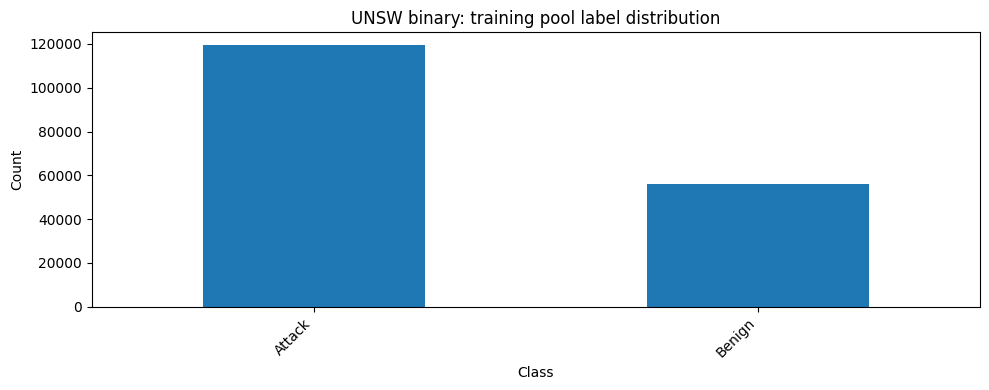

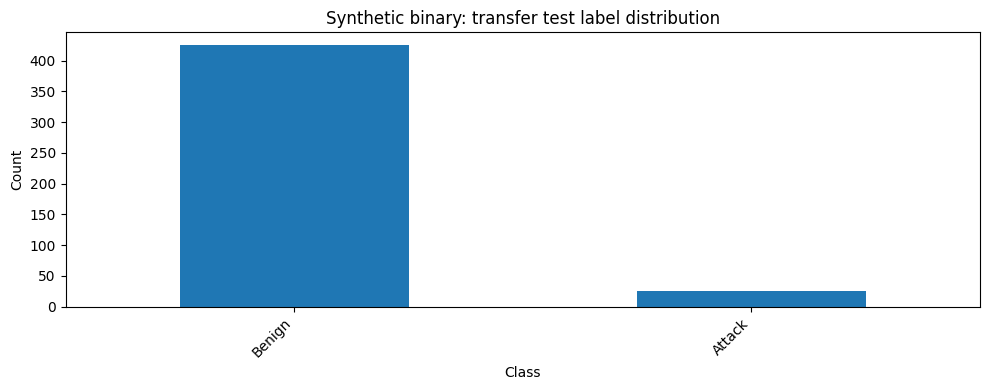

systems2024_arch1_1dcnn_seed_11 | epoch 01 | loss=0.1836 | val_acc=0.8888 | val_macro_f1=0.8804
systems2024_arch1_1dcnn_seed_11 | epoch 02 | loss=0.1370 | val_acc=0.8956 | val_macro_f1=0.8872
systems2024_arch1_1dcnn_seed_11 | epoch 03 | loss=0.1305 | val_acc=0.9132 | val_macro_f1=0.9050
systems2024_arch1_1dcnn_seed_11 | epoch 04 | loss=0.1283 | val_acc=0.9060 | val_macro_f1=0.8979
systems2024_arch1_1dcnn_seed_11 | epoch 05 | loss=0.1266 | val_acc=0.9127 | val_macro_f1=0.9046
systems2024_arch1_1dcnn_seed_11 | epoch 06 | loss=0.1232 | val_acc=0.9038 | val_macro_f1=0.8958
systems2024_arch1_1dcnn_seed_11 | epoch 07 | loss=0.1237 | val_acc=0.9087 | val_macro_f1=0.9006
Early stopping.


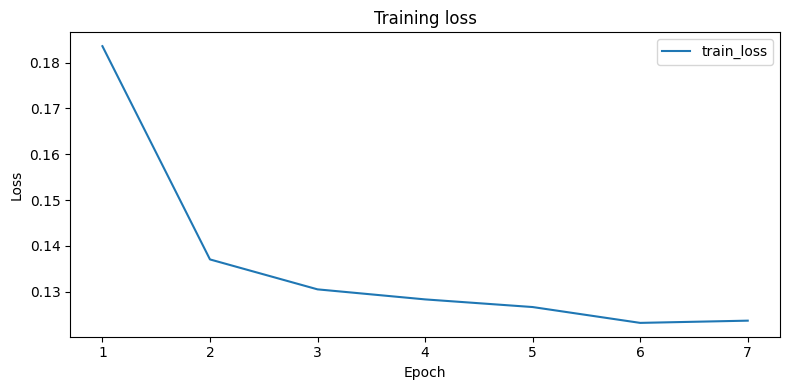

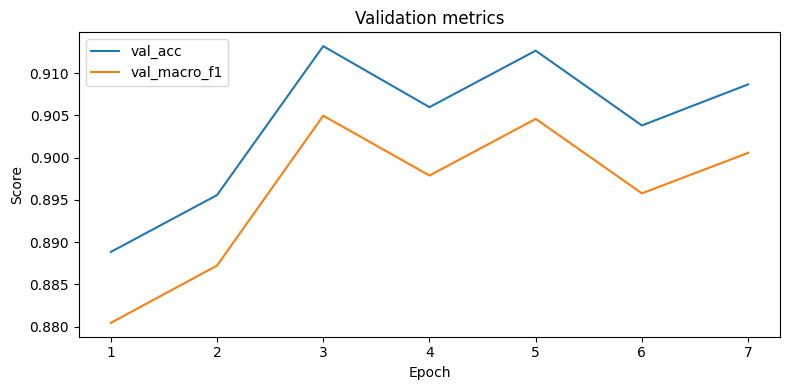

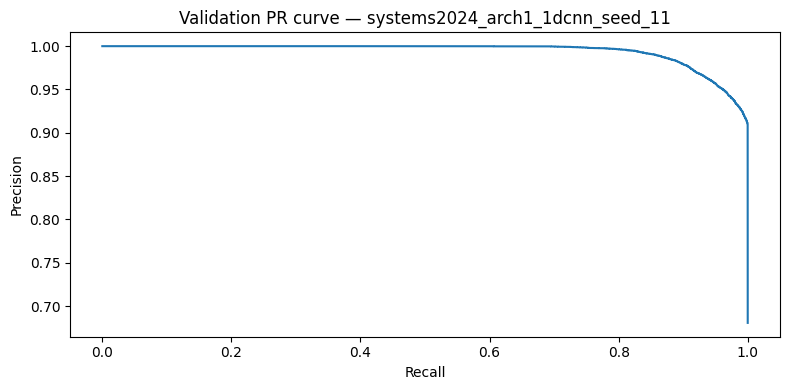

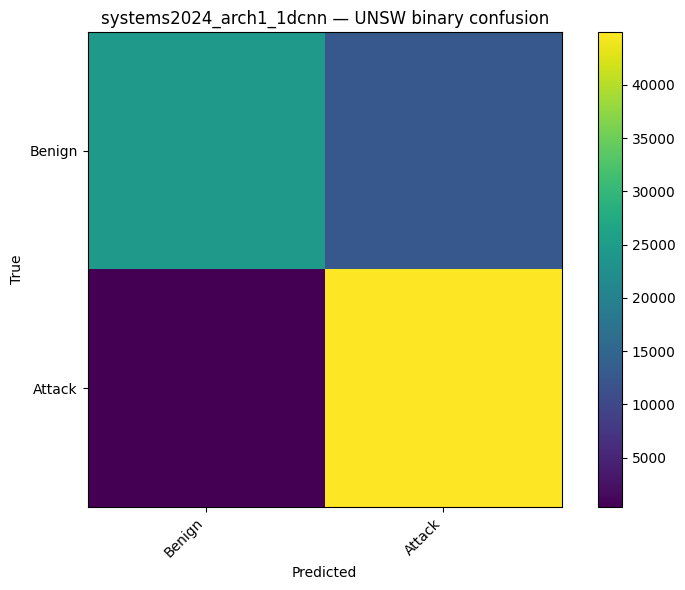

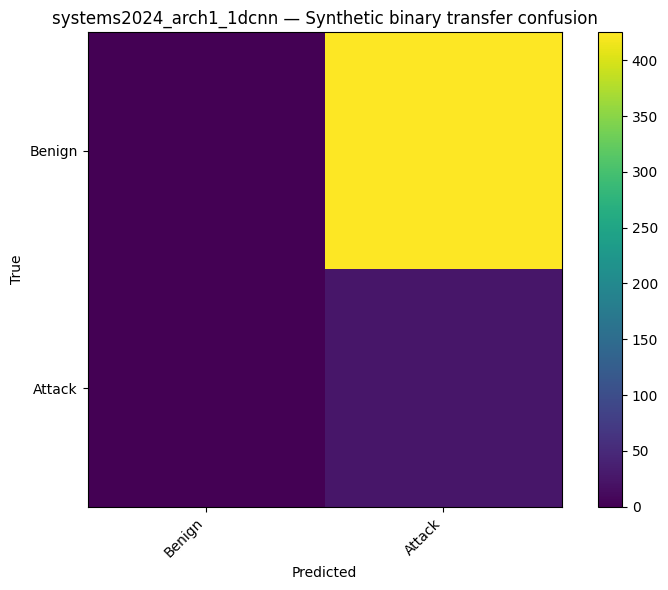

systems2024_arch1_1dcnn_seed_22 | epoch 01 | loss=0.1807 | val_acc=0.9143 | val_macro_f1=0.9058
systems2024_arch1_1dcnn_seed_22 | epoch 02 | loss=0.1374 | val_acc=0.9194 | val_macro_f1=0.9109
systems2024_arch1_1dcnn_seed_22 | epoch 03 | loss=0.1311 | val_acc=0.9126 | val_macro_f1=0.9045
systems2024_arch1_1dcnn_seed_22 | epoch 04 | loss=0.1291 | val_acc=0.9099 | val_macro_f1=0.9017
systems2024_arch1_1dcnn_seed_22 | epoch 05 | loss=0.1243 | val_acc=0.8993 | val_macro_f1=0.8913
systems2024_arch1_1dcnn_seed_22 | epoch 06 | loss=0.1230 | val_acc=0.9086 | val_macro_f1=0.9006
Early stopping.


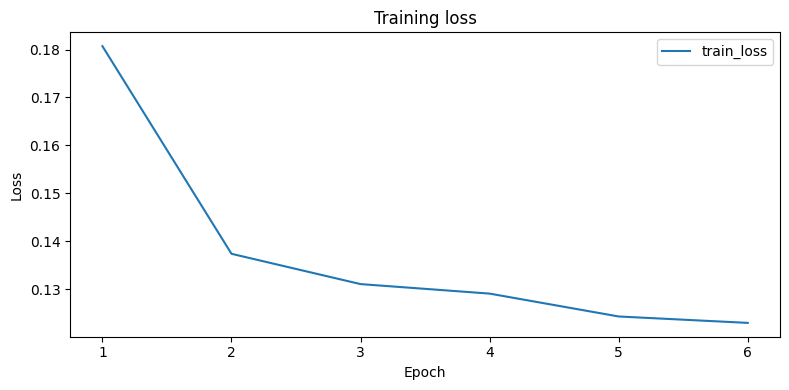

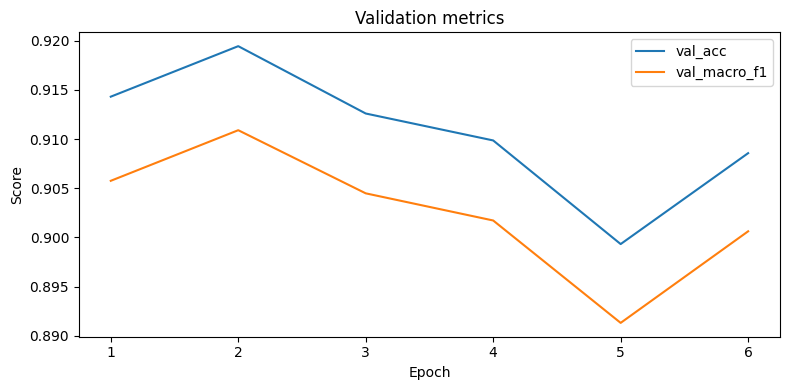

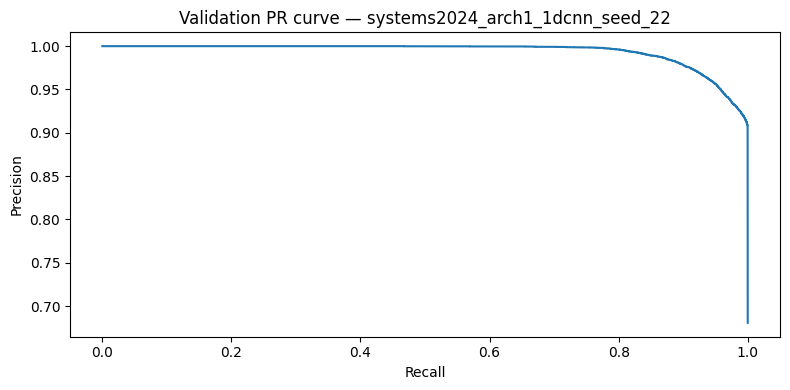

systems2024_arch1_1dcnn_seed_33 | epoch 01 | loss=0.1800 | val_acc=0.9146 | val_macro_f1=0.9061
systems2024_arch1_1dcnn_seed_33 | epoch 02 | loss=0.1351 | val_acc=0.9051 | val_macro_f1=0.8969
systems2024_arch1_1dcnn_seed_33 | epoch 03 | loss=0.1310 | val_acc=0.9188 | val_macro_f1=0.9106
systems2024_arch1_1dcnn_seed_33 | epoch 04 | loss=0.1257 | val_acc=0.9210 | val_macro_f1=0.9128
systems2024_arch1_1dcnn_seed_33 | epoch 05 | loss=0.1252 | val_acc=0.9164 | val_macro_f1=0.9084
systems2024_arch1_1dcnn_seed_33 | epoch 06 | loss=0.1235 | val_acc=0.9096 | val_macro_f1=0.9016
systems2024_arch1_1dcnn_seed_33 | epoch 07 | loss=0.1215 | val_acc=0.9087 | val_macro_f1=0.9007
systems2024_arch1_1dcnn_seed_33 | epoch 08 | loss=0.1204 | val_acc=0.9314 | val_macro_f1=0.9237
systems2024_arch1_1dcnn_seed_33 | epoch 09 | loss=0.1177 | val_acc=0.9199 | val_macro_f1=0.9119
systems2024_arch1_1dcnn_seed_33 | epoch 10 | loss=0.1171 | val_acc=0.9080 | val_macro_f1=0.9001
systems2024_arch1_1dcnn_seed_33 | epoch 

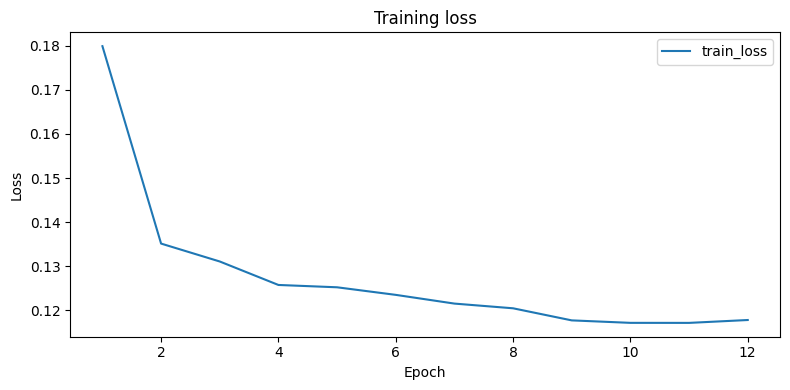

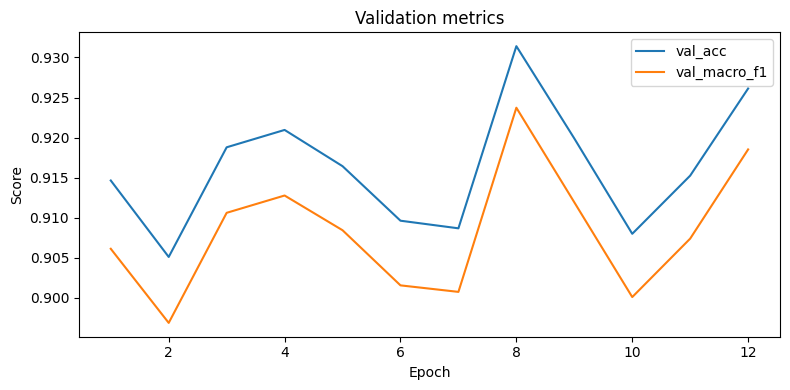

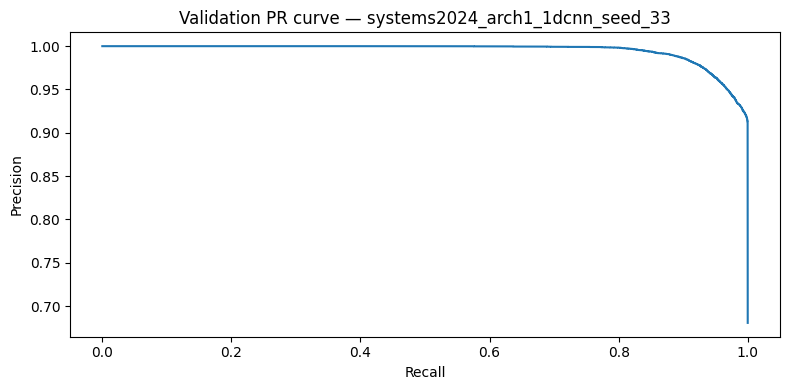

systems2024_arch1_1dcnn_seed_44 | epoch 01 | loss=0.1770 | val_acc=0.9088 | val_macro_f1=0.9002
systems2024_arch1_1dcnn_seed_44 | epoch 02 | loss=0.1336 | val_acc=0.9017 | val_macro_f1=0.8934
systems2024_arch1_1dcnn_seed_44 | epoch 03 | loss=0.1263 | val_acc=0.9140 | val_macro_f1=0.9057
systems2024_arch1_1dcnn_seed_44 | epoch 04 | loss=0.1248 | val_acc=0.9150 | val_macro_f1=0.9069
systems2024_arch1_1dcnn_seed_44 | epoch 05 | loss=0.1224 | val_acc=0.9102 | val_macro_f1=0.9021
systems2024_arch1_1dcnn_seed_44 | epoch 06 | loss=0.1212 | val_acc=0.9019 | val_macro_f1=0.8938
systems2024_arch1_1dcnn_seed_44 | epoch 07 | loss=0.1201 | val_acc=0.9189 | val_macro_f1=0.9109
systems2024_arch1_1dcnn_seed_44 | epoch 08 | loss=0.1178 | val_acc=0.9185 | val_macro_f1=0.9106
systems2024_arch1_1dcnn_seed_44 | epoch 09 | loss=0.1187 | val_acc=0.9166 | val_macro_f1=0.9086
systems2024_arch1_1dcnn_seed_44 | epoch 10 | loss=0.1183 | val_acc=0.9293 | val_macro_f1=0.9212
systems2024_arch1_1dcnn_seed_44 | epoch 

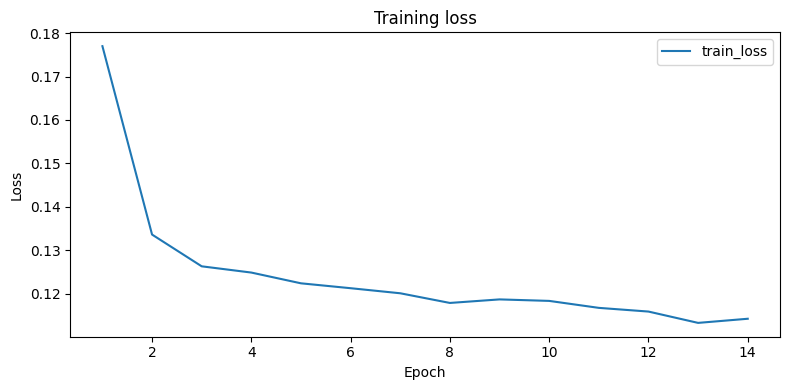

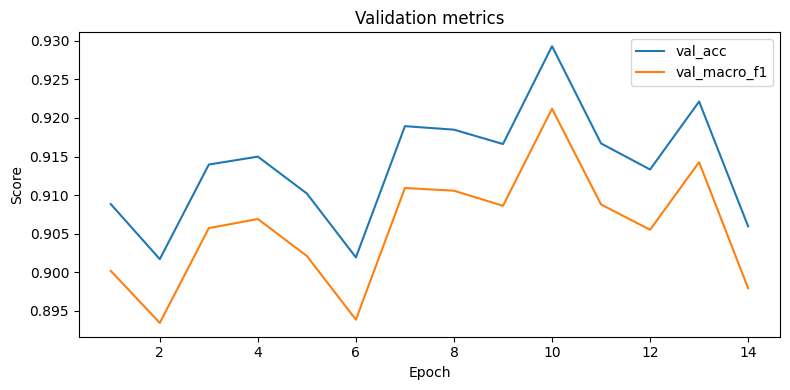

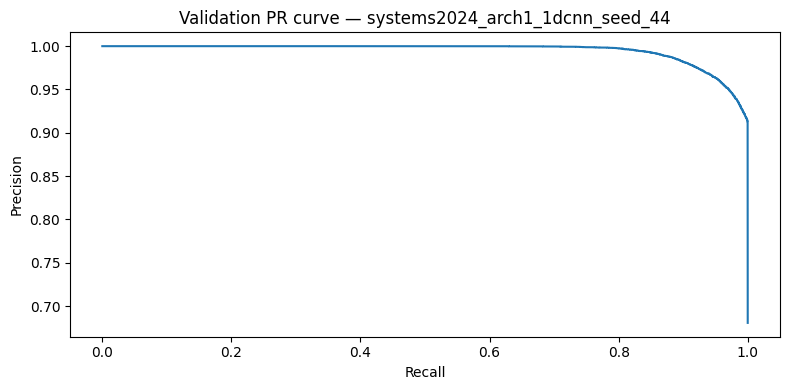

systems2024_arch1_1dcnn_seed_55 | epoch 01 | loss=0.1899 | val_acc=0.9158 | val_macro_f1=0.9072
systems2024_arch1_1dcnn_seed_55 | epoch 02 | loss=0.1386 | val_acc=0.9152 | val_macro_f1=0.9068
systems2024_arch1_1dcnn_seed_55 | epoch 03 | loss=0.1303 | val_acc=0.9099 | val_macro_f1=0.9018
systems2024_arch1_1dcnn_seed_55 | epoch 04 | loss=0.1280 | val_acc=0.9195 | val_macro_f1=0.9115
systems2024_arch1_1dcnn_seed_55 | epoch 05 | loss=0.1219 | val_acc=0.9092 | val_macro_f1=0.9012
systems2024_arch1_1dcnn_seed_55 | epoch 06 | loss=0.1247 | val_acc=0.9186 | val_macro_f1=0.9106
systems2024_arch1_1dcnn_seed_55 | epoch 07 | loss=0.1222 | val_acc=0.9125 | val_macro_f1=0.9045
systems2024_arch1_1dcnn_seed_55 | epoch 08 | loss=0.1210 | val_acc=0.9227 | val_macro_f1=0.9148
systems2024_arch1_1dcnn_seed_55 | epoch 09 | loss=0.1182 | val_acc=0.9206 | val_macro_f1=0.9127
systems2024_arch1_1dcnn_seed_55 | epoch 10 | loss=0.1182 | val_acc=0.9190 | val_macro_f1=0.9111
systems2024_arch1_1dcnn_seed_55 | epoch 

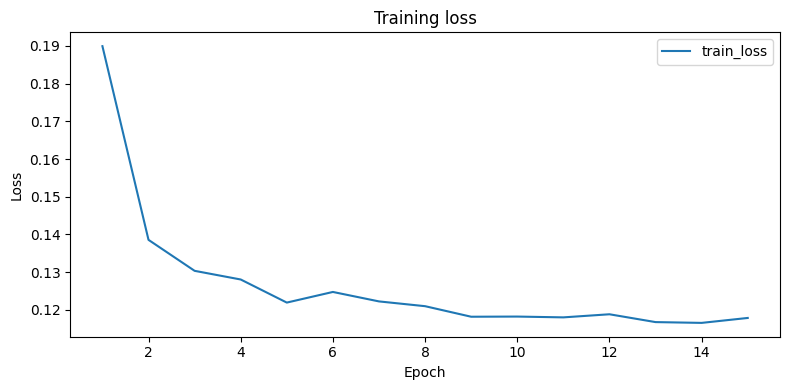

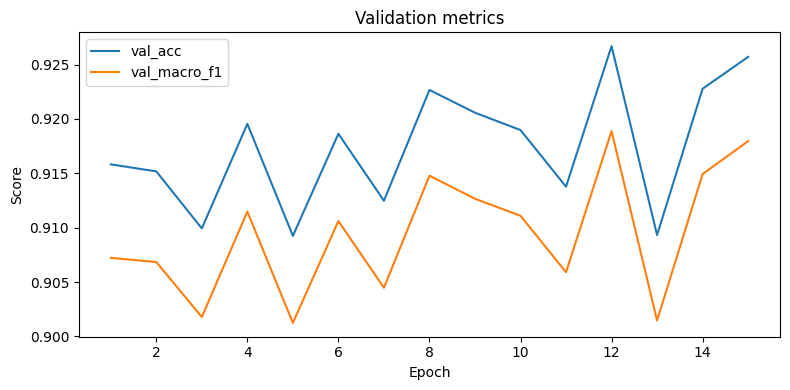

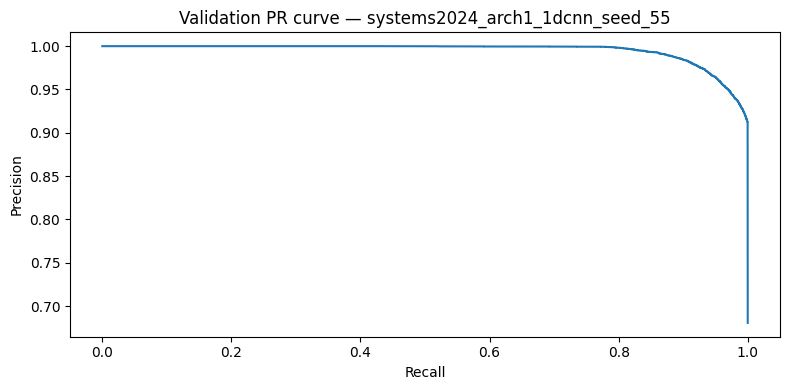

UNSW summary


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,systems2024_arch1_1dcnn,0.847658,0.010214,0.787634,0.011792,0.990656,0.001378,0.877514,0.007163


Synthetic transfer summary


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,rows_kept_mean,rows_total_mean
0,systems2024_arch1_1dcnn,0.055556,0.0,0.055556,0.0,1.0,0.0,0.105263,0.0,450.0,450.0


Running: systems2024_arch2_1dcnn | task: binary


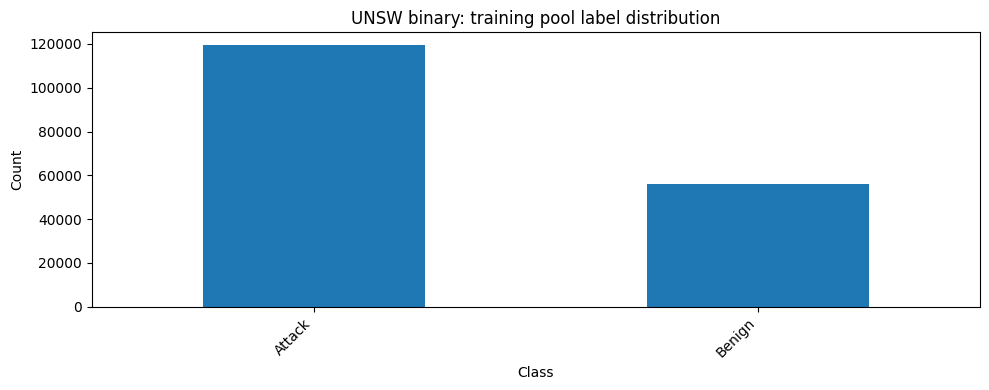

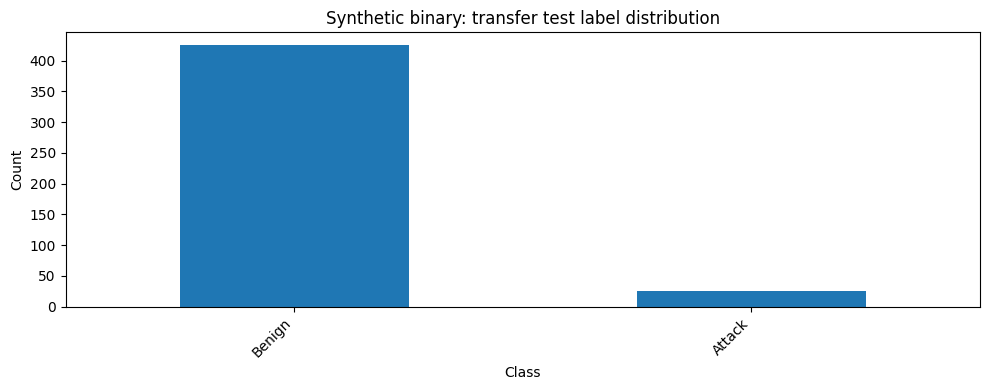

systems2024_arch2_1dcnn_seed_11 | epoch 01 | loss=0.1713 | val_acc=0.8955 | val_macro_f1=0.8872
systems2024_arch2_1dcnn_seed_11 | epoch 02 | loss=0.1300 | val_acc=0.9079 | val_macro_f1=0.8997
systems2024_arch2_1dcnn_seed_11 | epoch 03 | loss=0.1239 | val_acc=0.8987 | val_macro_f1=0.8906
systems2024_arch2_1dcnn_seed_11 | epoch 04 | loss=0.1217 | val_acc=0.9072 | val_macro_f1=0.8992
systems2024_arch2_1dcnn_seed_11 | epoch 05 | loss=0.1200 | val_acc=0.9092 | val_macro_f1=0.9013
systems2024_arch2_1dcnn_seed_11 | epoch 06 | loss=0.1172 | val_acc=0.9140 | val_macro_f1=0.9061
systems2024_arch2_1dcnn_seed_11 | epoch 07 | loss=0.1175 | val_acc=0.9212 | val_macro_f1=0.9134
systems2024_arch2_1dcnn_seed_11 | epoch 08 | loss=0.1155 | val_acc=0.9145 | val_macro_f1=0.9063
systems2024_arch2_1dcnn_seed_11 | epoch 09 | loss=0.1137 | val_acc=0.9182 | val_macro_f1=0.9104
systems2024_arch2_1dcnn_seed_11 | epoch 10 | loss=0.1143 | val_acc=0.9207 | val_macro_f1=0.9128
systems2024_arch2_1dcnn_seed_11 | epoch 

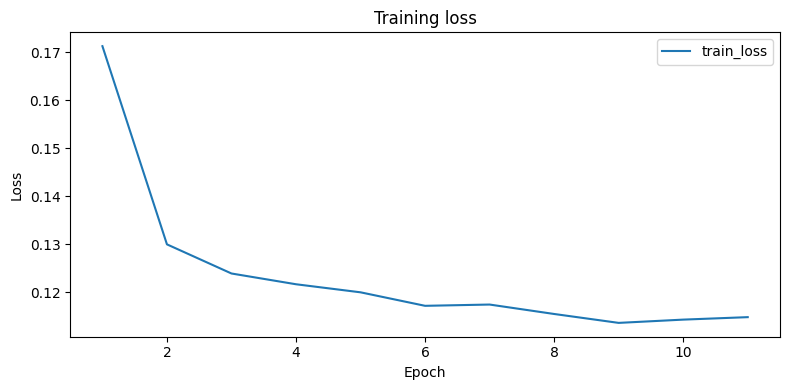

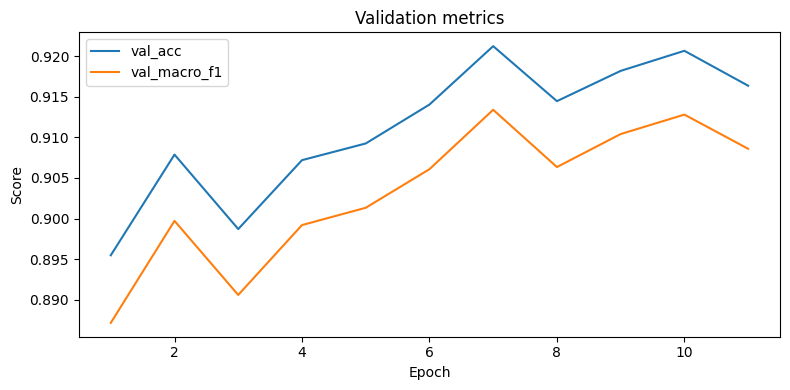

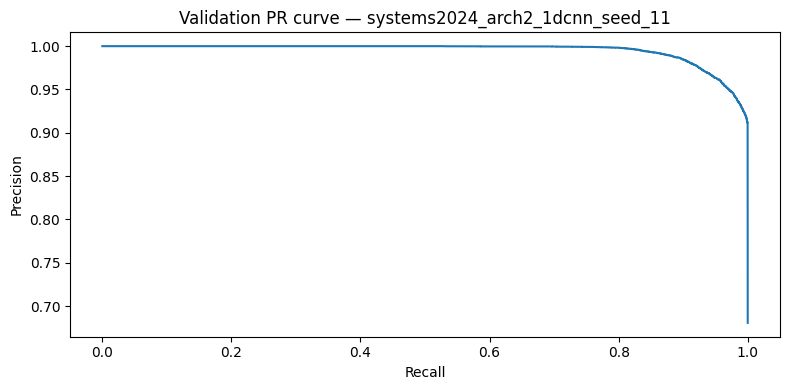

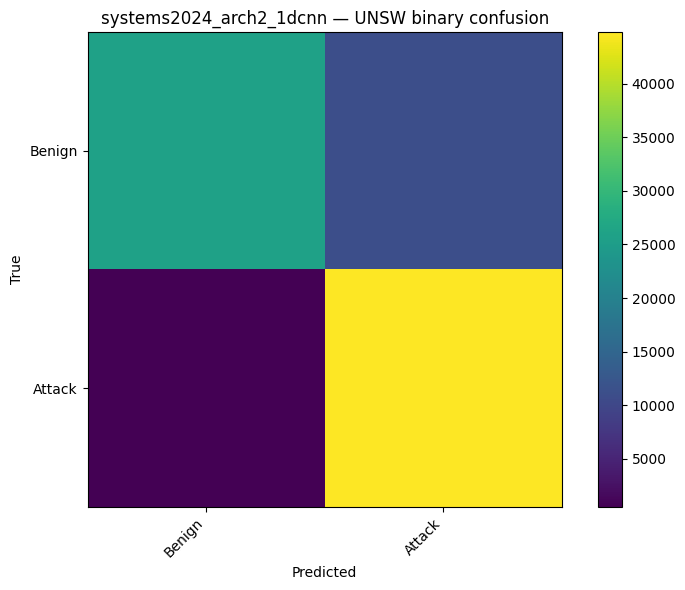

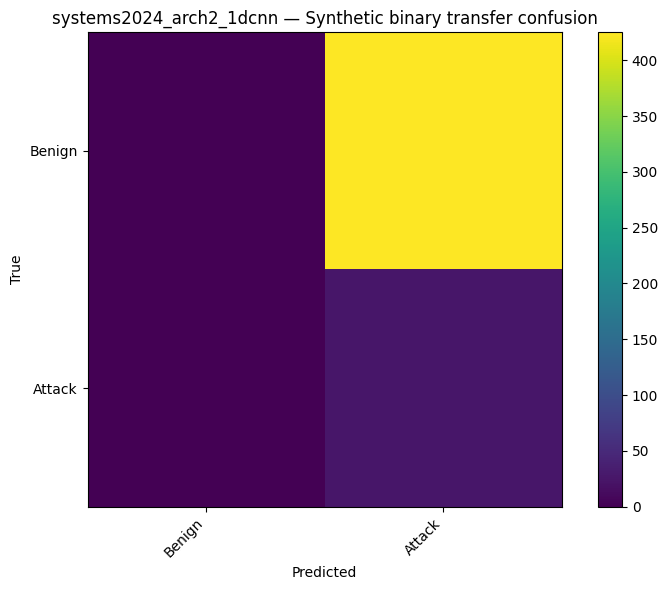

systems2024_arch2_1dcnn_seed_22 | epoch 01 | loss=0.1742 | val_acc=0.8942 | val_macro_f1=0.8860
systems2024_arch2_1dcnn_seed_22 | epoch 02 | loss=0.1329 | val_acc=0.8947 | val_macro_f1=0.8867
systems2024_arch2_1dcnn_seed_22 | epoch 03 | loss=0.1260 | val_acc=0.9080 | val_macro_f1=0.8999
systems2024_arch2_1dcnn_seed_22 | epoch 04 | loss=0.1235 | val_acc=0.9082 | val_macro_f1=0.9002
systems2024_arch2_1dcnn_seed_22 | epoch 05 | loss=0.1202 | val_acc=0.9067 | val_macro_f1=0.8989
systems2024_arch2_1dcnn_seed_22 | epoch 06 | loss=0.1194 | val_acc=0.9132 | val_macro_f1=0.9052
systems2024_arch2_1dcnn_seed_22 | epoch 07 | loss=0.1190 | val_acc=0.9088 | val_macro_f1=0.9010
systems2024_arch2_1dcnn_seed_22 | epoch 08 | loss=0.1165 | val_acc=0.9188 | val_macro_f1=0.9108
systems2024_arch2_1dcnn_seed_22 | epoch 09 | loss=0.1168 | val_acc=0.9247 | val_macro_f1=0.9168
systems2024_arch2_1dcnn_seed_22 | epoch 10 | loss=0.1155 | val_acc=0.9210 | val_macro_f1=0.9132
systems2024_arch2_1dcnn_seed_22 | epoch 

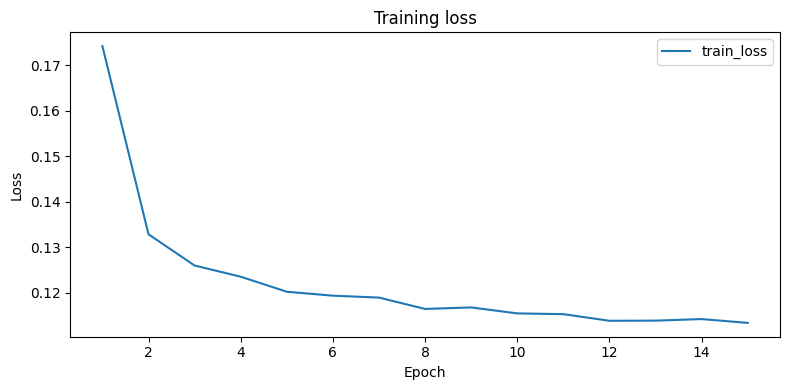

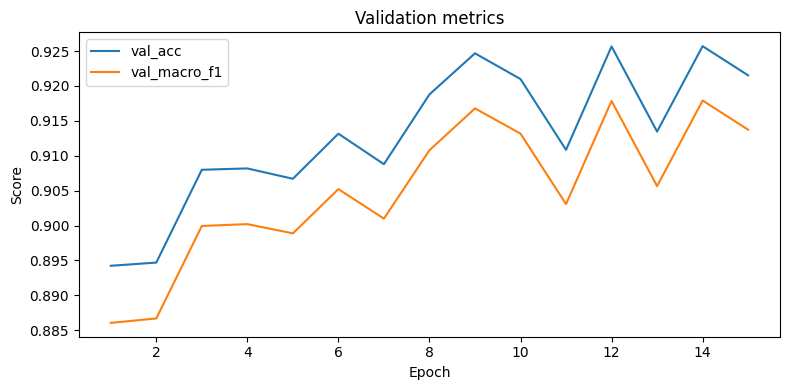

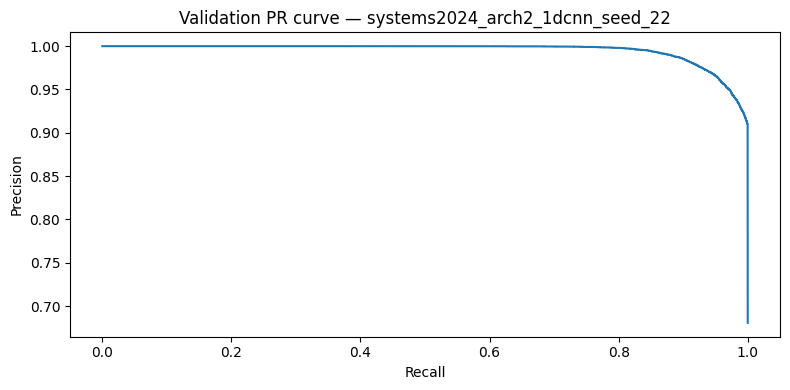

systems2024_arch2_1dcnn_seed_33 | epoch 01 | loss=0.1751 | val_acc=0.9102 | val_macro_f1=0.9017
systems2024_arch2_1dcnn_seed_33 | epoch 02 | loss=0.1324 | val_acc=0.8917 | val_macro_f1=0.8837
systems2024_arch2_1dcnn_seed_33 | epoch 03 | loss=0.1271 | val_acc=0.9092 | val_macro_f1=0.9012
systems2024_arch2_1dcnn_seed_33 | epoch 04 | loss=0.1241 | val_acc=0.9218 | val_macro_f1=0.9138
systems2024_arch2_1dcnn_seed_33 | epoch 05 | loss=0.1230 | val_acc=0.9123 | val_macro_f1=0.9043
systems2024_arch2_1dcnn_seed_33 | epoch 06 | loss=0.1195 | val_acc=0.9232 | val_macro_f1=0.9154
systems2024_arch2_1dcnn_seed_33 | epoch 07 | loss=0.1189 | val_acc=0.9268 | val_macro_f1=0.9192
systems2024_arch2_1dcnn_seed_33 | epoch 08 | loss=0.1183 | val_acc=0.9059 | val_macro_f1=0.8981
systems2024_arch2_1dcnn_seed_33 | epoch 09 | loss=0.1145 | val_acc=0.9215 | val_macro_f1=0.9138
systems2024_arch2_1dcnn_seed_33 | epoch 10 | loss=0.1154 | val_acc=0.9204 | val_macro_f1=0.9129
systems2024_arch2_1dcnn_seed_33 | epoch 

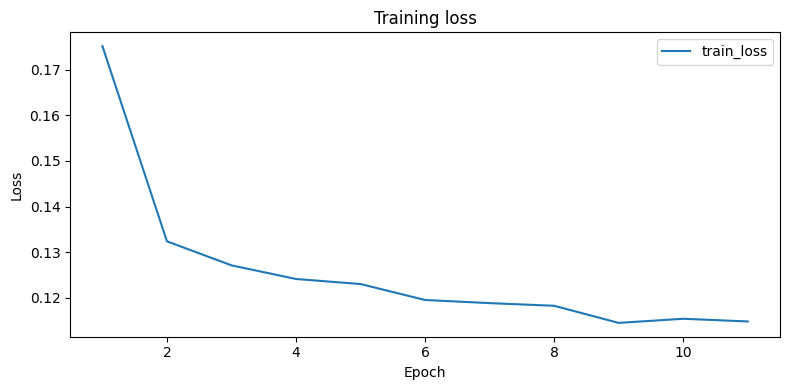

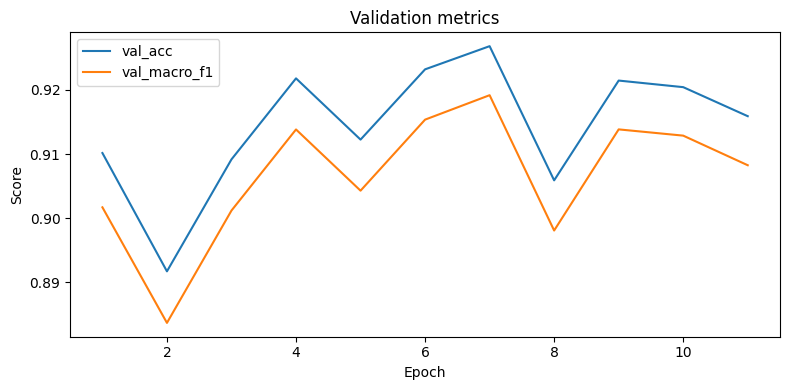

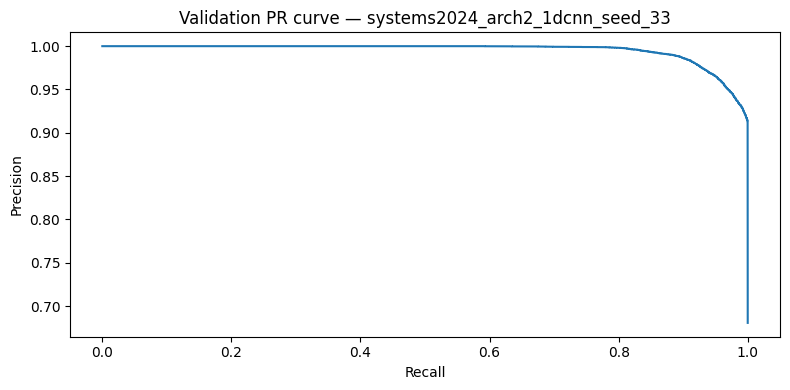

systems2024_arch2_1dcnn_seed_44 | epoch 01 | loss=0.1732 | val_acc=0.8871 | val_macro_f1=0.8787
systems2024_arch2_1dcnn_seed_44 | epoch 02 | loss=0.1312 | val_acc=0.8933 | val_macro_f1=0.8852
systems2024_arch2_1dcnn_seed_44 | epoch 03 | loss=0.1241 | val_acc=0.9143 | val_macro_f1=0.9062
systems2024_arch2_1dcnn_seed_44 | epoch 04 | loss=0.1239 | val_acc=0.8999 | val_macro_f1=0.8918
systems2024_arch2_1dcnn_seed_44 | epoch 05 | loss=0.1223 | val_acc=0.9019 | val_macro_f1=0.8940
systems2024_arch2_1dcnn_seed_44 | epoch 06 | loss=0.1213 | val_acc=0.9170 | val_macro_f1=0.9091
systems2024_arch2_1dcnn_seed_44 | epoch 07 | loss=0.1196 | val_acc=0.9083 | val_macro_f1=0.9003
systems2024_arch2_1dcnn_seed_44 | epoch 08 | loss=0.1162 | val_acc=0.9067 | val_macro_f1=0.8989
systems2024_arch2_1dcnn_seed_44 | epoch 09 | loss=0.1166 | val_acc=0.9076 | val_macro_f1=0.8996
systems2024_arch2_1dcnn_seed_44 | epoch 10 | loss=0.1165 | val_acc=0.9107 | val_macro_f1=0.9028
Early stopping.


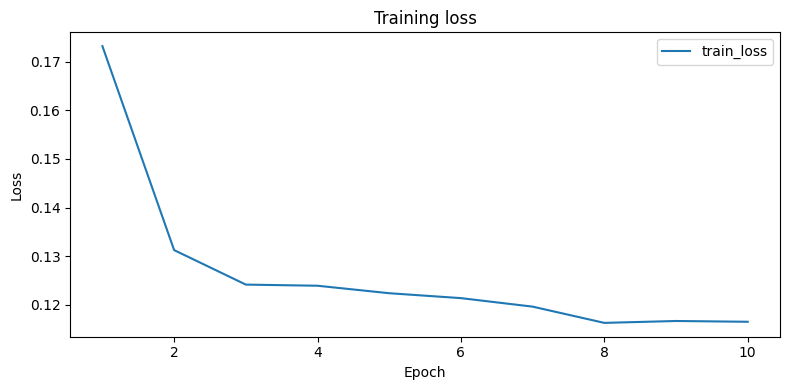

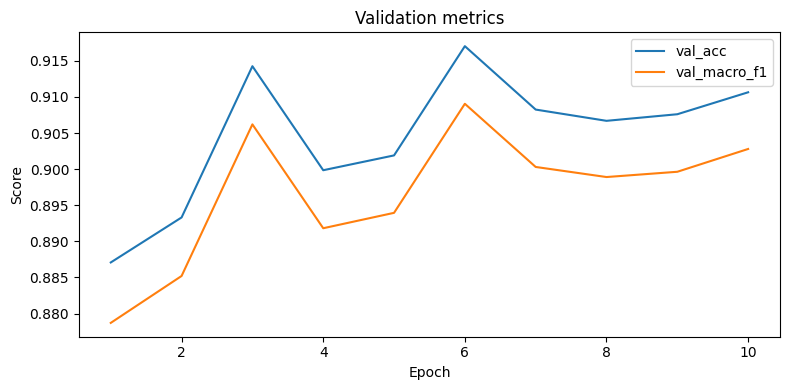

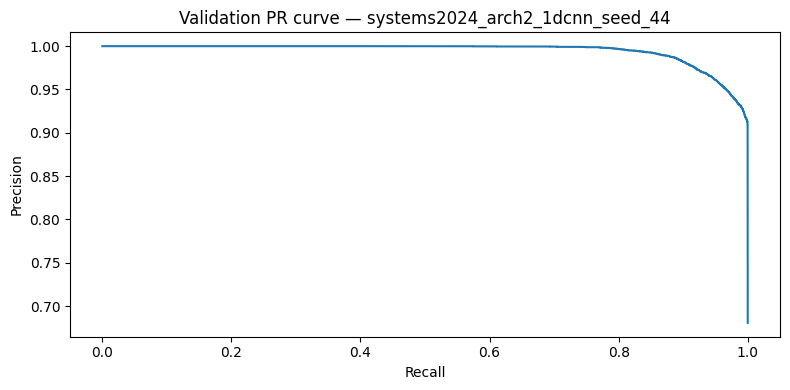

systems2024_arch2_1dcnn_seed_55 | epoch 01 | loss=0.1757 | val_acc=0.8825 | val_macro_f1=0.8744
systems2024_arch2_1dcnn_seed_55 | epoch 02 | loss=0.1320 | val_acc=0.8955 | val_macro_f1=0.8873
systems2024_arch2_1dcnn_seed_55 | epoch 03 | loss=0.1261 | val_acc=0.9161 | val_macro_f1=0.9081
systems2024_arch2_1dcnn_seed_55 | epoch 04 | loss=0.1245 | val_acc=0.9026 | val_macro_f1=0.8946
systems2024_arch2_1dcnn_seed_55 | epoch 05 | loss=0.1190 | val_acc=0.9123 | val_macro_f1=0.9044
systems2024_arch2_1dcnn_seed_55 | epoch 06 | loss=0.1222 | val_acc=0.9057 | val_macro_f1=0.8978
systems2024_arch2_1dcnn_seed_55 | epoch 07 | loss=0.1211 | val_acc=0.9085 | val_macro_f1=0.9005
Early stopping.


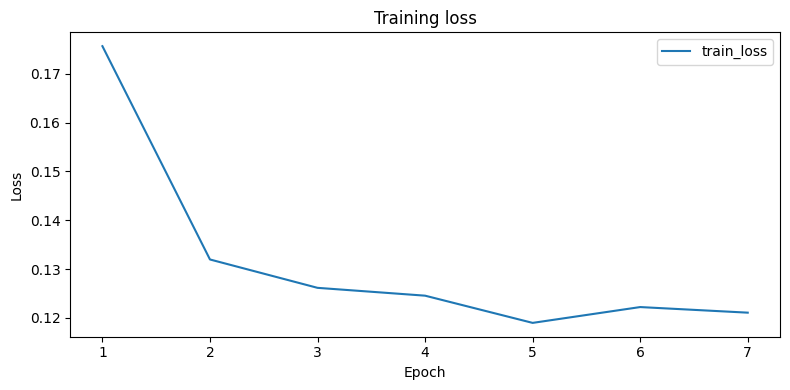

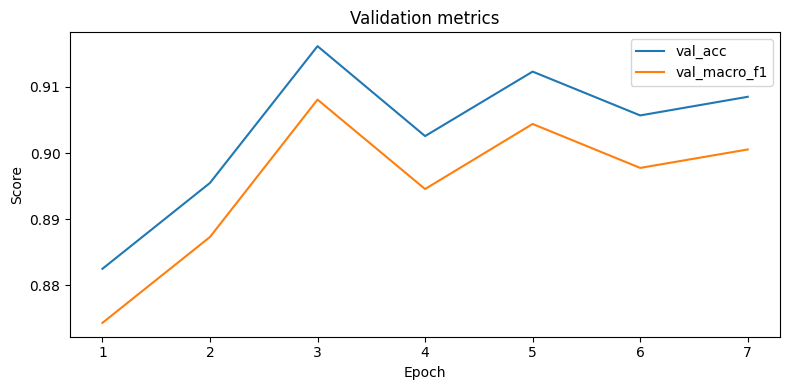

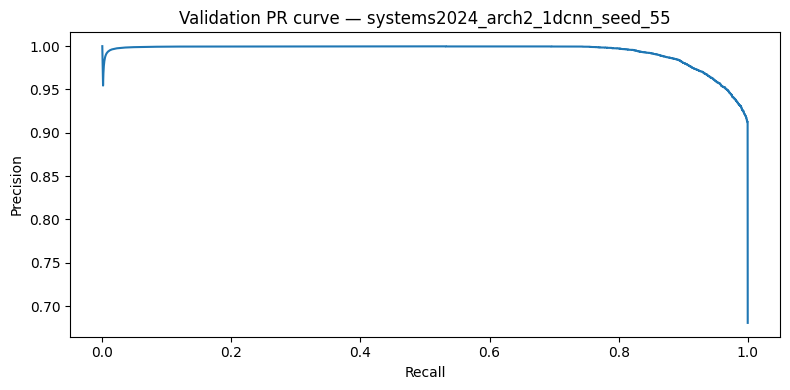

UNSW summary


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,systems2024_arch2_1dcnn,0.852191,0.012212,0.793184,0.014935,0.990122,0.002473,0.880699,0.008343


Synthetic transfer summary


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,rows_kept_mean,rows_total_mean
0,systems2024_arch2_1dcnn,0.055556,0.0,0.055556,0.0,1.0,0.0,0.105263,0.0,450.0,450.0


Running: noever2021_mobilenetv2_image | task: binary


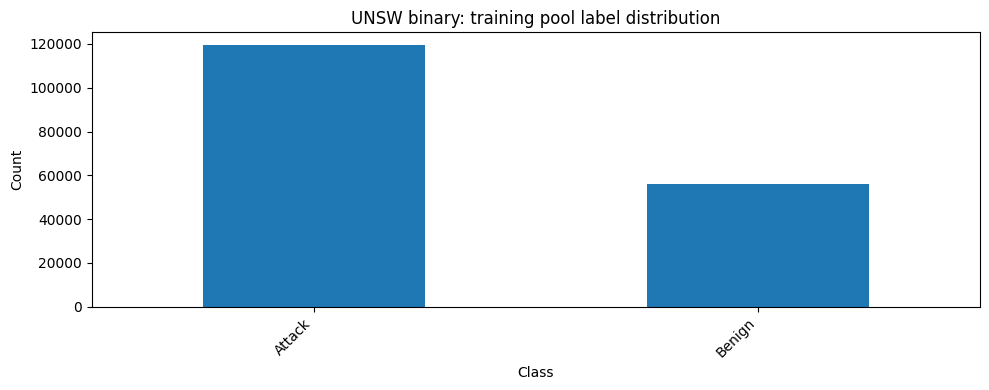

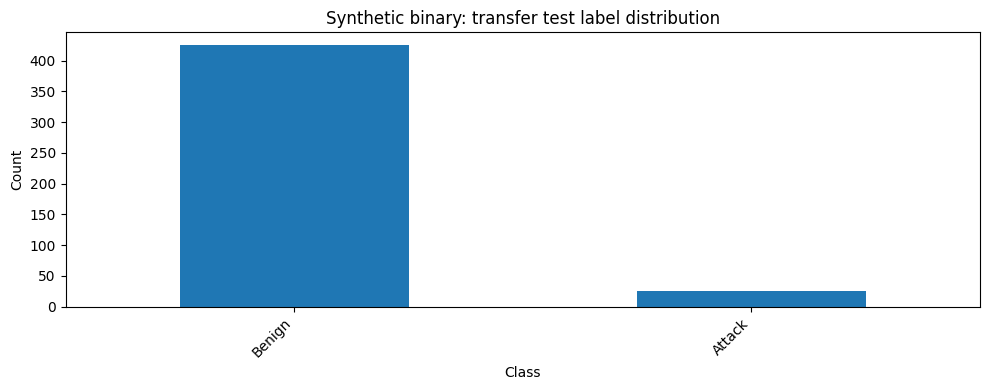

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 223MB/s]


noever2021_mobilenetv2_image_seed_11 | epoch 01 | loss=0.1528 | val_acc=0.8932 | val_macro_f1=0.8850
noever2021_mobilenetv2_image_seed_11 | epoch 02 | loss=0.1340 | val_acc=0.9126 | val_macro_f1=0.9045
noever2021_mobilenetv2_image_seed_11 | epoch 03 | loss=0.1272 | val_acc=0.9171 | val_macro_f1=0.9092
noever2021_mobilenetv2_image_seed_11 | epoch 04 | loss=0.1267 | val_acc=0.9043 | val_macro_f1=0.8962
noever2021_mobilenetv2_image_seed_11 | epoch 05 | loss=0.1253 | val_acc=0.8914 | val_macro_f1=0.8834
noever2021_mobilenetv2_image_seed_11 | epoch 06 | loss=0.1239 | val_acc=0.9122 | val_macro_f1=0.9041
noever2021_mobilenetv2_image_seed_11 | epoch 07 | loss=0.1210 | val_acc=0.9205 | val_macro_f1=0.9126
noever2021_mobilenetv2_image_seed_11 | epoch 08 | loss=0.1202 | val_acc=0.9146 | val_macro_f1=0.9066
noever2021_mobilenetv2_image_seed_11 | epoch 09 | loss=0.1191 | val_acc=0.9240 | val_macro_f1=0.9162
noever2021_mobilenetv2_image_seed_11 | epoch 10 | loss=0.1206 | val_acc=0.9019 | val_macro_

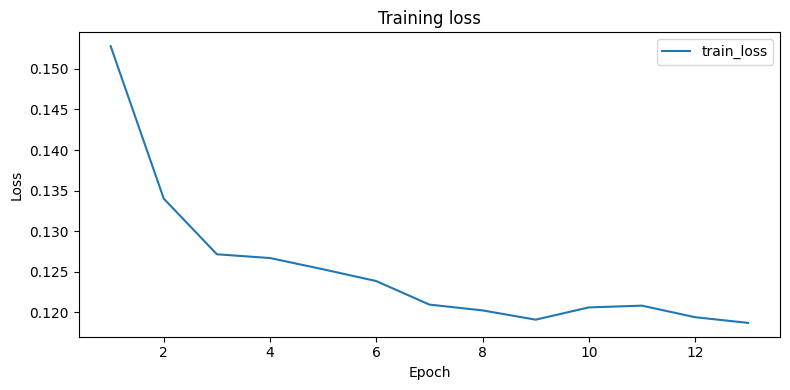

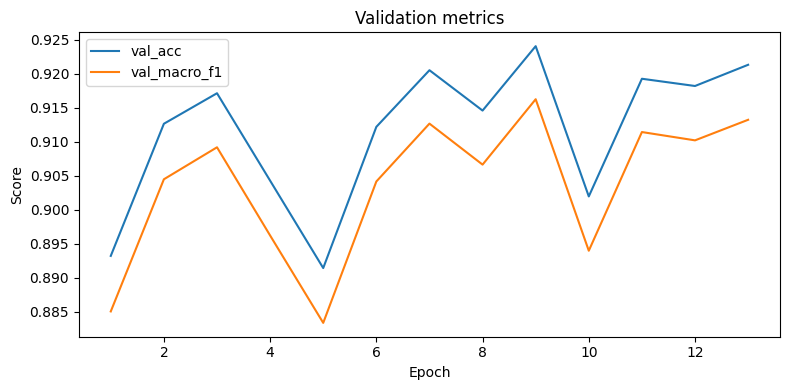

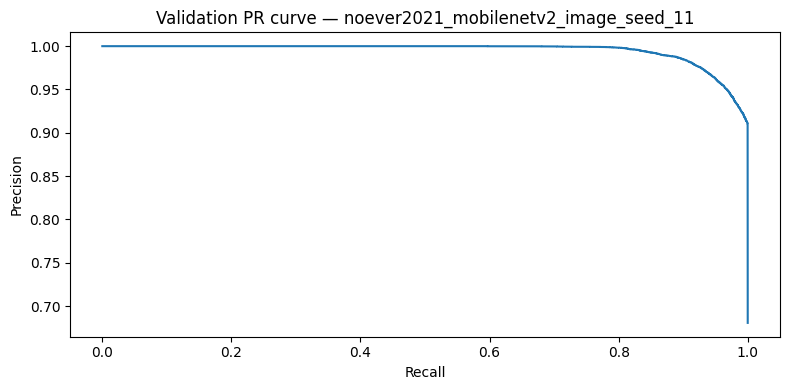

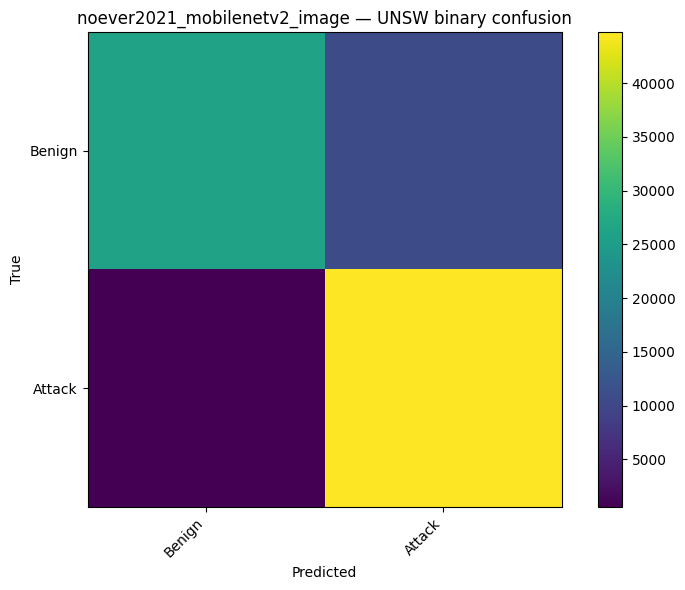

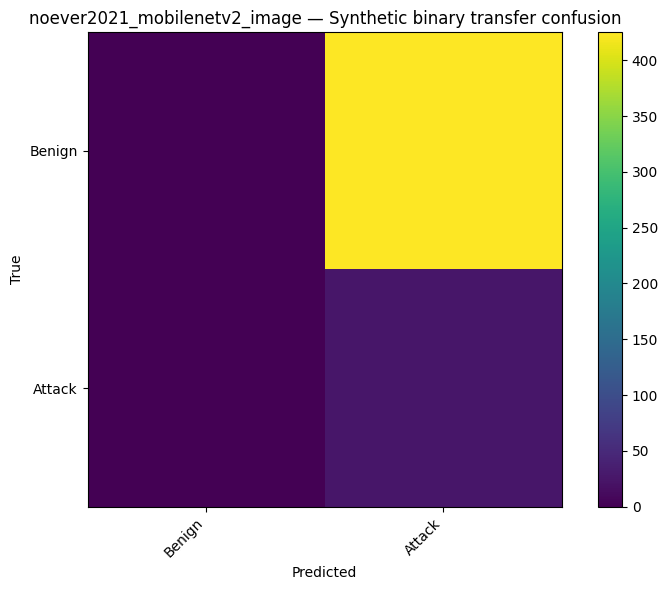

noever2021_mobilenetv2_image_seed_22 | epoch 01 | loss=0.1589 | val_acc=0.9288 | val_macro_f1=0.9203
noever2021_mobilenetv2_image_seed_22 | epoch 02 | loss=0.1388 | val_acc=0.9161 | val_macro_f1=0.9080
noever2021_mobilenetv2_image_seed_22 | epoch 03 | loss=0.1281 | val_acc=0.9199 | val_macro_f1=0.9119
noever2021_mobilenetv2_image_seed_22 | epoch 04 | loss=0.1264 | val_acc=0.9214 | val_macro_f1=0.9134
noever2021_mobilenetv2_image_seed_22 | epoch 05 | loss=0.1226 | val_acc=0.9156 | val_macro_f1=0.9076
Early stopping.


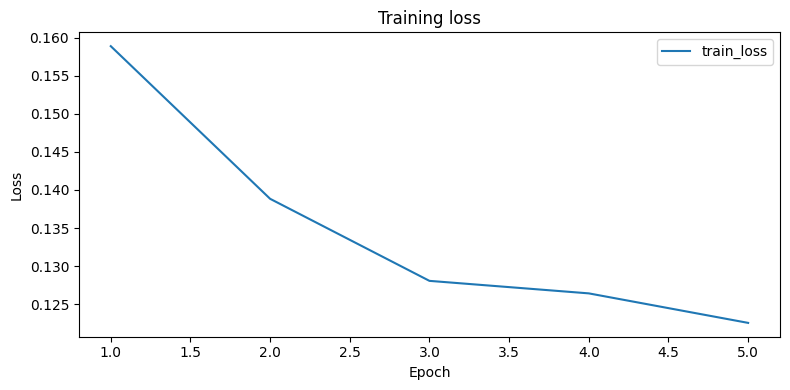

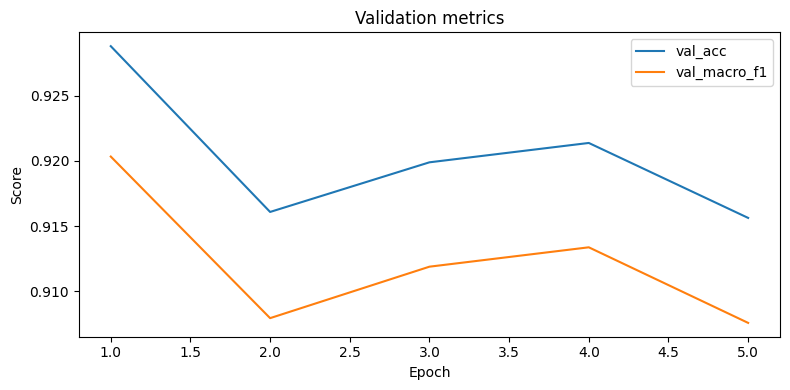

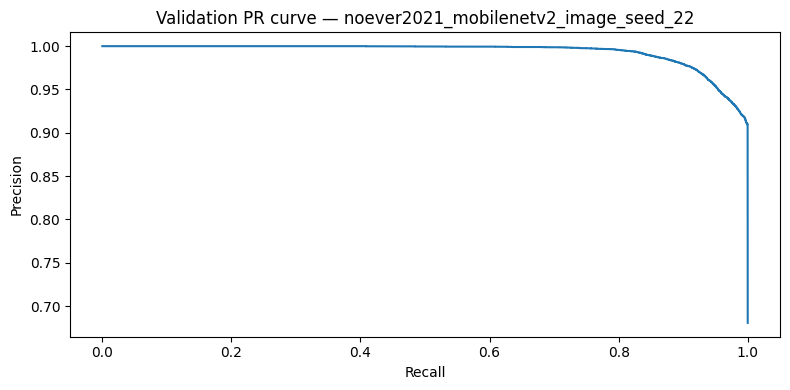

noever2021_mobilenetv2_image_seed_33 | epoch 01 | loss=0.1564 | val_acc=0.8900 | val_macro_f1=0.8816
noever2021_mobilenetv2_image_seed_33 | epoch 02 | loss=0.1315 | val_acc=0.9175 | val_macro_f1=0.9096
noever2021_mobilenetv2_image_seed_33 | epoch 03 | loss=0.1264 | val_acc=0.9268 | val_macro_f1=0.9189
noever2021_mobilenetv2_image_seed_33 | epoch 04 | loss=0.1257 | val_acc=0.9239 | val_macro_f1=0.9160
noever2021_mobilenetv2_image_seed_33 | epoch 05 | loss=0.1236 | val_acc=0.9242 | val_macro_f1=0.9162
noever2021_mobilenetv2_image_seed_33 | epoch 06 | loss=0.1222 | val_acc=0.9226 | val_macro_f1=0.9148
noever2021_mobilenetv2_image_seed_33 | epoch 07 | loss=0.1224 | val_acc=0.9326 | val_macro_f1=0.9249
noever2021_mobilenetv2_image_seed_33 | epoch 08 | loss=0.1188 | val_acc=0.8939 | val_macro_f1=0.8861
noever2021_mobilenetv2_image_seed_33 | epoch 09 | loss=0.1212 | val_acc=0.9267 | val_macro_f1=0.9189
noever2021_mobilenetv2_image_seed_33 | epoch 10 | loss=0.1210 | val_acc=0.9170 | val_macro_

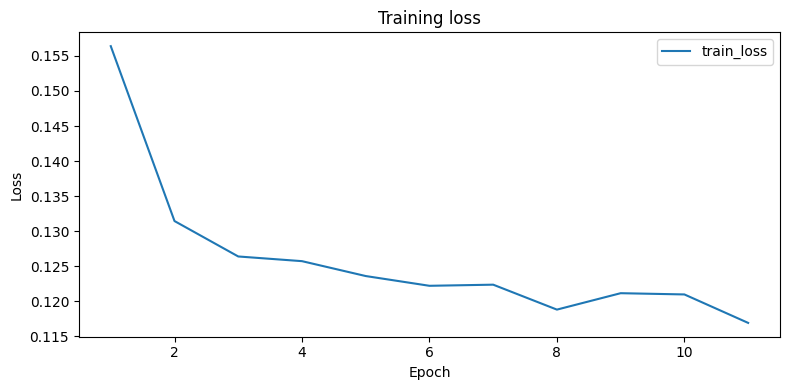

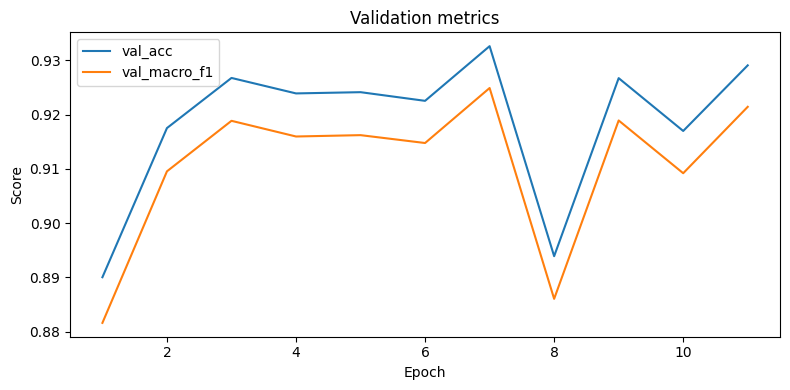

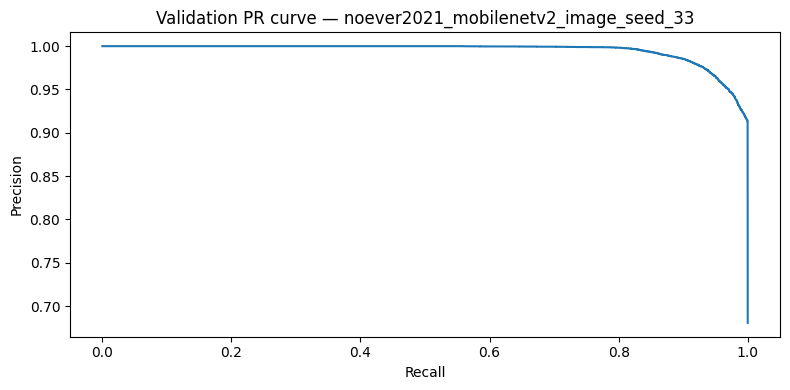

noever2021_mobilenetv2_image_seed_44 | epoch 01 | loss=0.1561 | val_acc=0.9010 | val_macro_f1=0.8927
noever2021_mobilenetv2_image_seed_44 | epoch 02 | loss=0.1339 | val_acc=0.9135 | val_macro_f1=0.9053
noever2021_mobilenetv2_image_seed_44 | epoch 03 | loss=0.1285 | val_acc=0.9147 | val_macro_f1=0.9066
noever2021_mobilenetv2_image_seed_44 | epoch 04 | loss=0.1248 | val_acc=0.9143 | val_macro_f1=0.9063
noever2021_mobilenetv2_image_seed_44 | epoch 05 | loss=0.1216 | val_acc=0.9283 | val_macro_f1=0.9204
noever2021_mobilenetv2_image_seed_44 | epoch 06 | loss=0.1230 | val_acc=0.9083 | val_macro_f1=0.9003
noever2021_mobilenetv2_image_seed_44 | epoch 07 | loss=0.1211 | val_acc=0.9240 | val_macro_f1=0.9161
noever2021_mobilenetv2_image_seed_44 | epoch 08 | loss=0.1221 | val_acc=0.9185 | val_macro_f1=0.9106
noever2021_mobilenetv2_image_seed_44 | epoch 09 | loss=0.1200 | val_acc=0.9224 | val_macro_f1=0.9145
Early stopping.


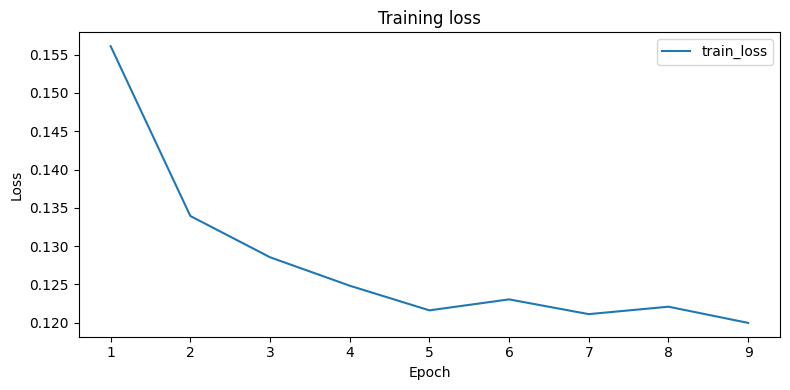

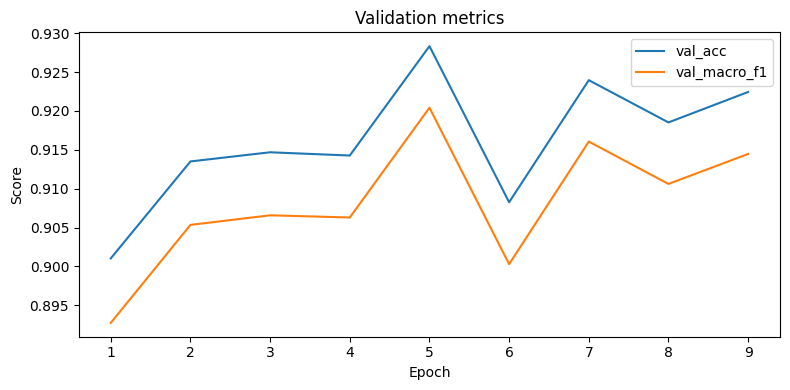

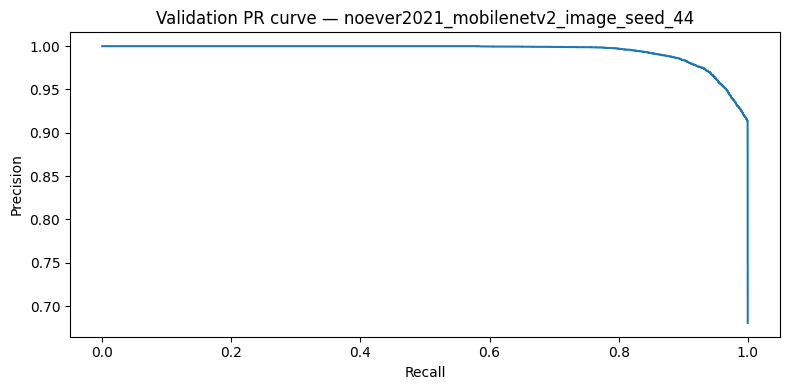

noever2021_mobilenetv2_image_seed_55 | epoch 01 | loss=0.1562 | val_acc=0.9052 | val_macro_f1=0.8971
noever2021_mobilenetv2_image_seed_55 | epoch 02 | loss=0.1350 | val_acc=0.9085 | val_macro_f1=0.9004
noever2021_mobilenetv2_image_seed_55 | epoch 03 | loss=0.1301 | val_acc=0.9036 | val_macro_f1=0.8955
noever2021_mobilenetv2_image_seed_55 | epoch 04 | loss=0.1259 | val_acc=0.9158 | val_macro_f1=0.9076
noever2021_mobilenetv2_image_seed_55 | epoch 05 | loss=0.1241 | val_acc=0.9288 | val_macro_f1=0.9209
noever2021_mobilenetv2_image_seed_55 | epoch 06 | loss=0.1224 | val_acc=0.9097 | val_macro_f1=0.9018
noever2021_mobilenetv2_image_seed_55 | epoch 07 | loss=0.1221 | val_acc=0.8968 | val_macro_f1=0.8889
noever2021_mobilenetv2_image_seed_55 | epoch 08 | loss=0.1227 | val_acc=0.9140 | val_macro_f1=0.9060
noever2021_mobilenetv2_image_seed_55 | epoch 09 | loss=0.1205 | val_acc=0.9268 | val_macro_f1=0.9188
Early stopping.


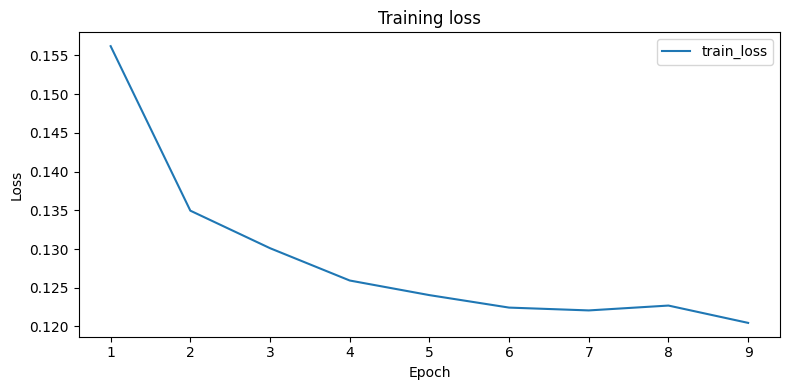

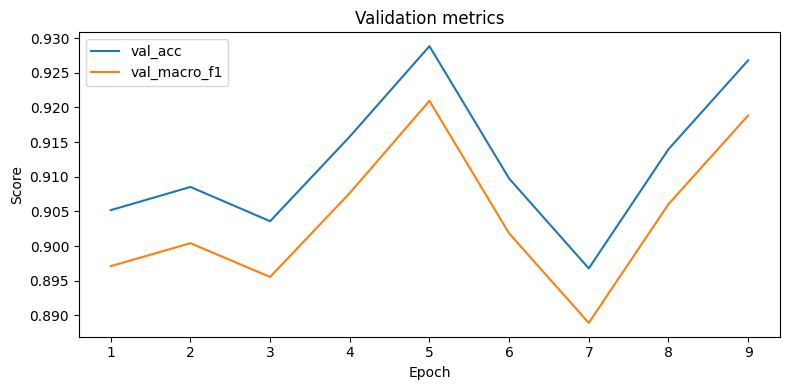

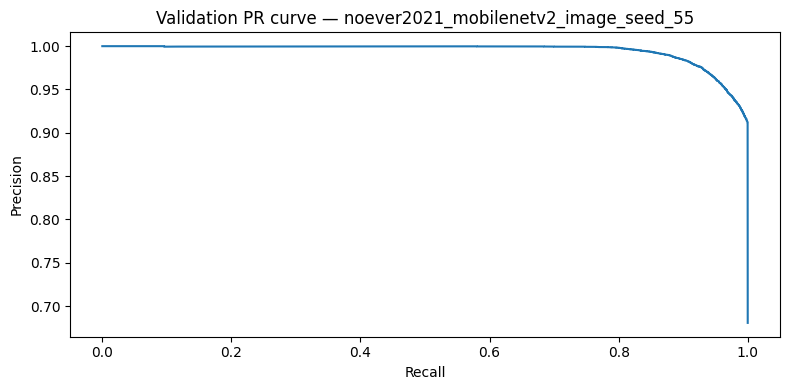

UNSW summary


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,noever2021_mobilenetv2_image,0.857181,0.010616,0.800392,0.012819,0.987025,0.003883,0.883914,0.007679


Synthetic transfer summary


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,rows_kept_mean,rows_total_mean
0,noever2021_mobilenetv2_image,0.588889,0.486864,0.022222,0.030429,0.4,0.547723,0.042105,0.057655,450.0,450.0


Running: systems2024_arch1_1dcnn | task: multiclass


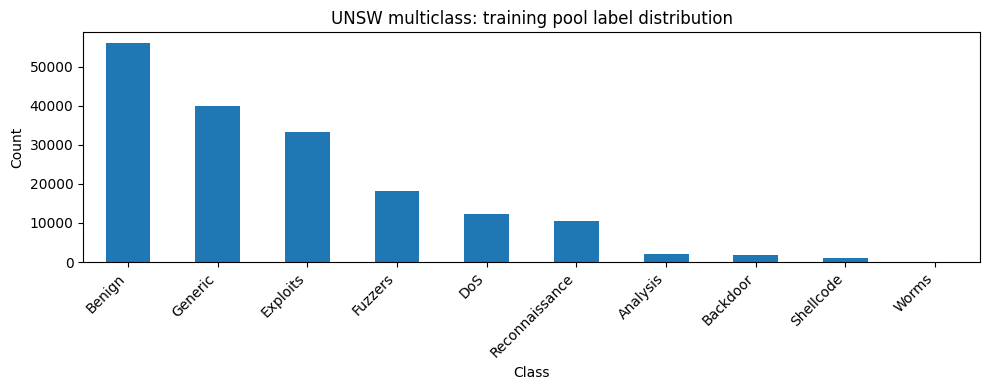

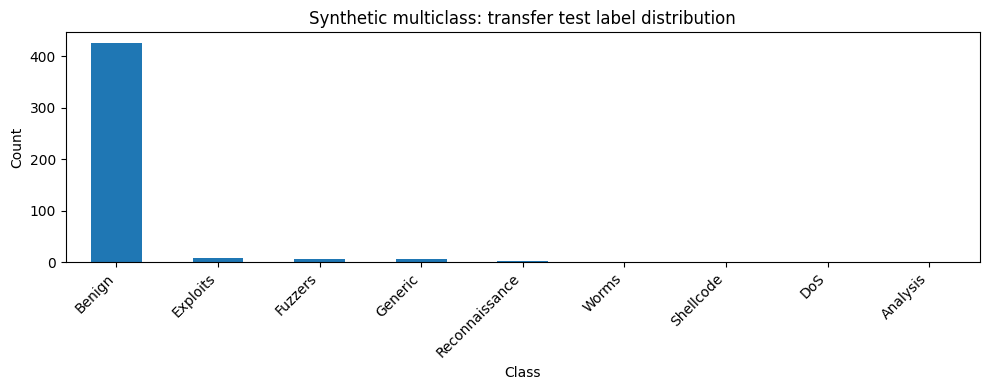

systems2024_arch1_1dcnn_seed_11 | epoch 01 | loss=0.4292 | val_acc=0.2587 | val_macro_f1=0.1247
systems2024_arch1_1dcnn_seed_11 | epoch 02 | loss=0.2854 | val_acc=0.4685 | val_macro_f1=0.2143
systems2024_arch1_1dcnn_seed_11 | epoch 03 | loss=0.2553 | val_acc=0.4981 | val_macro_f1=0.2442
systems2024_arch1_1dcnn_seed_11 | epoch 04 | loss=0.2420 | val_acc=0.5120 | val_macro_f1=0.2499
systems2024_arch1_1dcnn_seed_11 | epoch 05 | loss=0.2219 | val_acc=0.5286 | val_macro_f1=0.2664
systems2024_arch1_1dcnn_seed_11 | epoch 06 | loss=0.2138 | val_acc=0.5458 | val_macro_f1=0.2809
systems2024_arch1_1dcnn_seed_11 | epoch 07 | loss=0.2090 | val_acc=0.5650 | val_macro_f1=0.3000
systems2024_arch1_1dcnn_seed_11 | epoch 08 | loss=0.1995 | val_acc=0.5696 | val_macro_f1=0.3042
systems2024_arch1_1dcnn_seed_11 | epoch 09 | loss=0.1980 | val_acc=0.5746 | val_macro_f1=0.3071
systems2024_arch1_1dcnn_seed_11 | epoch 10 | loss=0.1891 | val_acc=0.5769 | val_macro_f1=0.3068
systems2024_arch1_1dcnn_seed_11 | epoch 

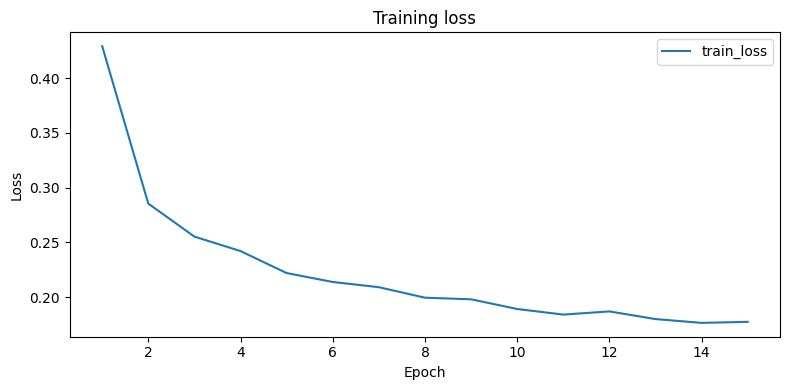

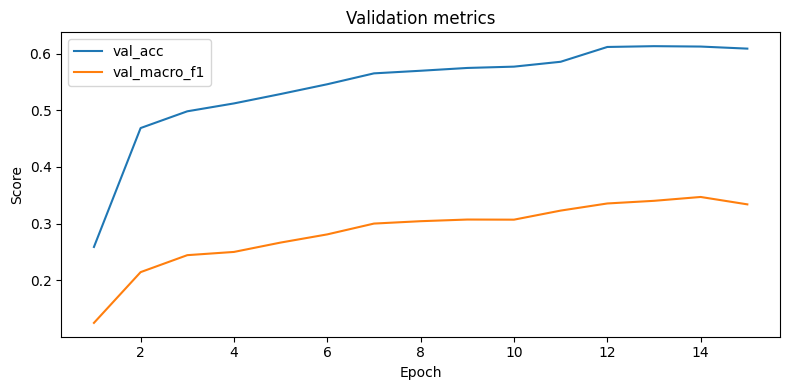

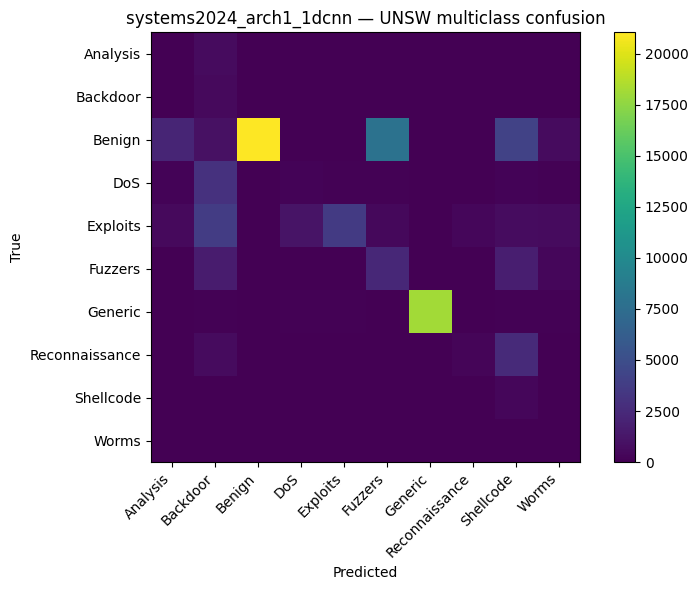

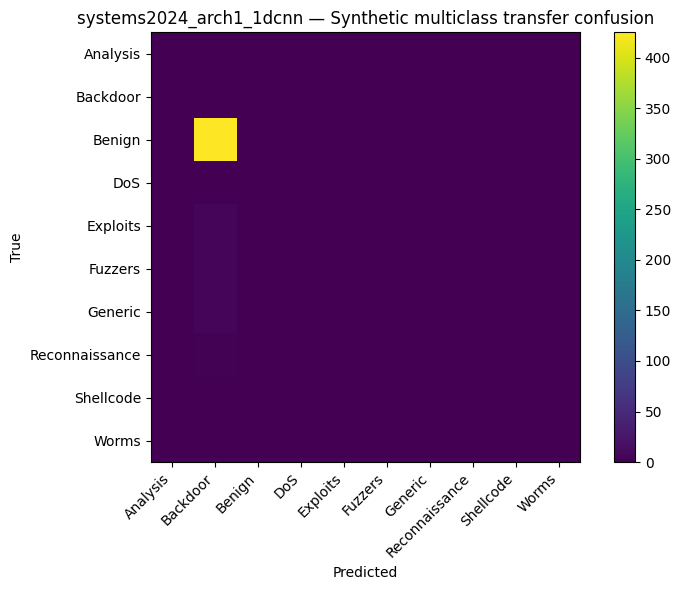

systems2024_arch1_1dcnn_seed_22 | epoch 01 | loss=0.4528 | val_acc=0.2271 | val_macro_f1=0.1124
systems2024_arch1_1dcnn_seed_22 | epoch 02 | loss=0.2923 | val_acc=0.2649 | val_macro_f1=0.1339
systems2024_arch1_1dcnn_seed_22 | epoch 03 | loss=0.2579 | val_acc=0.4140 | val_macro_f1=0.1955
systems2024_arch1_1dcnn_seed_22 | epoch 04 | loss=0.2448 | val_acc=0.5068 | val_macro_f1=0.2412
systems2024_arch1_1dcnn_seed_22 | epoch 05 | loss=0.2266 | val_acc=0.5502 | val_macro_f1=0.2832
systems2024_arch1_1dcnn_seed_22 | epoch 06 | loss=0.2147 | val_acc=0.5676 | val_macro_f1=0.3007
systems2024_arch1_1dcnn_seed_22 | epoch 07 | loss=0.2058 | val_acc=0.5770 | val_macro_f1=0.3082
systems2024_arch1_1dcnn_seed_22 | epoch 08 | loss=0.2001 | val_acc=0.5935 | val_macro_f1=0.3231
systems2024_arch1_1dcnn_seed_22 | epoch 09 | loss=0.1955 | val_acc=0.5825 | val_macro_f1=0.3236
systems2024_arch1_1dcnn_seed_22 | epoch 10 | loss=0.1879 | val_acc=0.5692 | val_macro_f1=0.3127
systems2024_arch1_1dcnn_seed_22 | epoch 

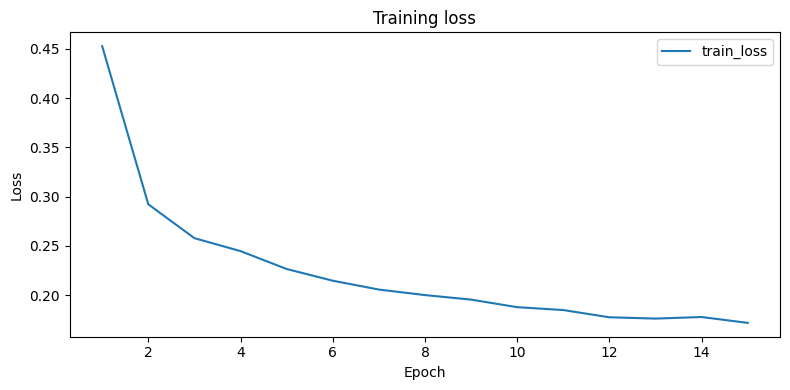

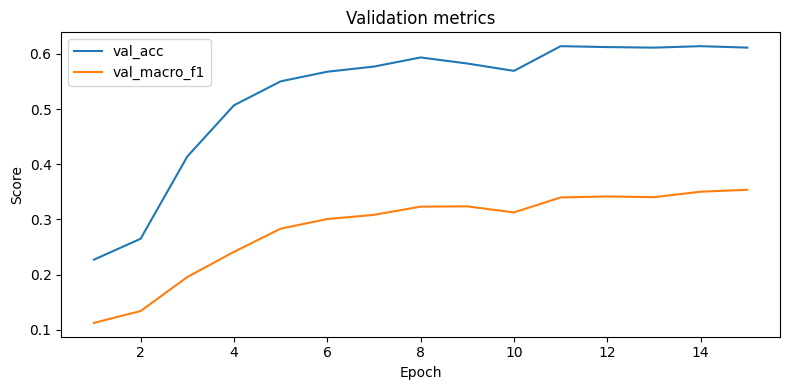

systems2024_arch1_1dcnn_seed_33 | epoch 01 | loss=0.4454 | val_acc=0.2303 | val_macro_f1=0.1079
systems2024_arch1_1dcnn_seed_33 | epoch 02 | loss=0.2860 | val_acc=0.2398 | val_macro_f1=0.1136
systems2024_arch1_1dcnn_seed_33 | epoch 03 | loss=0.2613 | val_acc=0.2429 | val_macro_f1=0.1189
systems2024_arch1_1dcnn_seed_33 | epoch 04 | loss=0.2476 | val_acc=0.5151 | val_macro_f1=0.2446
systems2024_arch1_1dcnn_seed_33 | epoch 05 | loss=0.2329 | val_acc=0.5386 | val_macro_f1=0.2730
systems2024_arch1_1dcnn_seed_33 | epoch 06 | loss=0.2215 | val_acc=0.5438 | val_macro_f1=0.2791
systems2024_arch1_1dcnn_seed_33 | epoch 07 | loss=0.2171 | val_acc=0.5661 | val_macro_f1=0.2989
systems2024_arch1_1dcnn_seed_33 | epoch 08 | loss=0.2059 | val_acc=0.5896 | val_macro_f1=0.3177
systems2024_arch1_1dcnn_seed_33 | epoch 09 | loss=0.2002 | val_acc=0.5898 | val_macro_f1=0.3186
systems2024_arch1_1dcnn_seed_33 | epoch 10 | loss=0.1927 | val_acc=0.6047 | val_macro_f1=0.3342
systems2024_arch1_1dcnn_seed_33 | epoch 

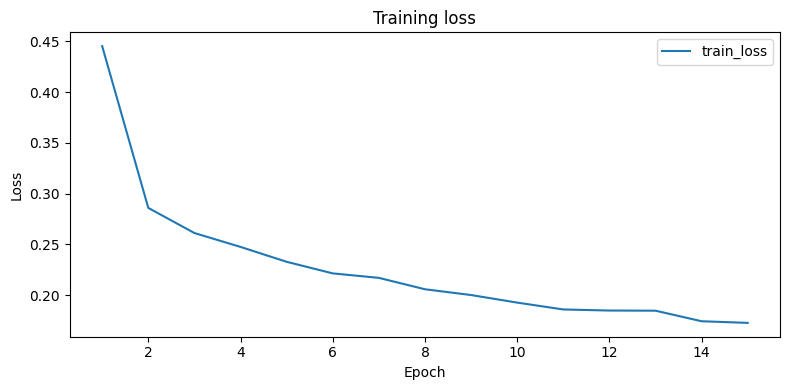

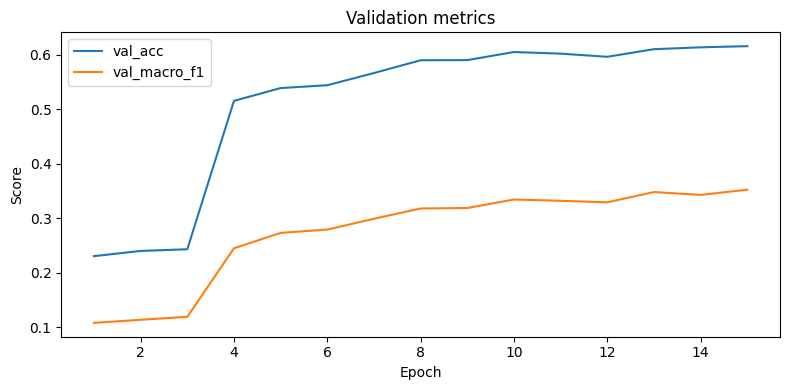

systems2024_arch1_1dcnn_seed_44 | epoch 01 | loss=0.4171 | val_acc=0.2481 | val_macro_f1=0.1216
systems2024_arch1_1dcnn_seed_44 | epoch 02 | loss=0.2891 | val_acc=0.4754 | val_macro_f1=0.2066
systems2024_arch1_1dcnn_seed_44 | epoch 03 | loss=0.2616 | val_acc=0.4832 | val_macro_f1=0.2137
systems2024_arch1_1dcnn_seed_44 | epoch 04 | loss=0.2445 | val_acc=0.4854 | val_macro_f1=0.2200
systems2024_arch1_1dcnn_seed_44 | epoch 05 | loss=0.2357 | val_acc=0.5202 | val_macro_f1=0.2554
systems2024_arch1_1dcnn_seed_44 | epoch 06 | loss=0.2138 | val_acc=0.5833 | val_macro_f1=0.3129
systems2024_arch1_1dcnn_seed_44 | epoch 07 | loss=0.2150 | val_acc=0.5757 | val_macro_f1=0.3143
systems2024_arch1_1dcnn_seed_44 | epoch 08 | loss=0.2047 | val_acc=0.5984 | val_macro_f1=0.3223
systems2024_arch1_1dcnn_seed_44 | epoch 09 | loss=0.1956 | val_acc=0.6058 | val_macro_f1=0.3331
systems2024_arch1_1dcnn_seed_44 | epoch 10 | loss=0.1856 | val_acc=0.5913 | val_macro_f1=0.3190
systems2024_arch1_1dcnn_seed_44 | epoch 

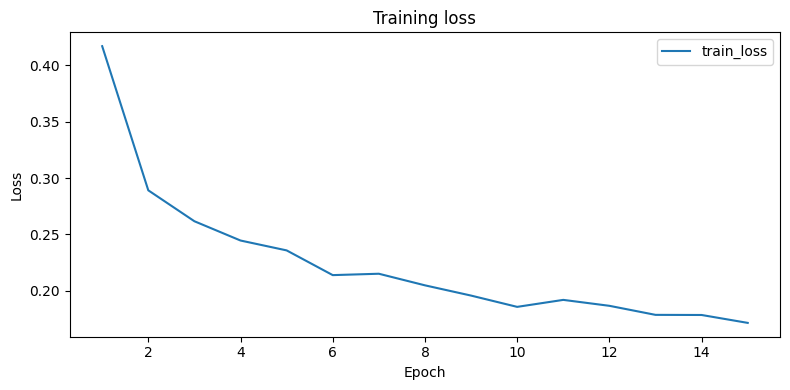

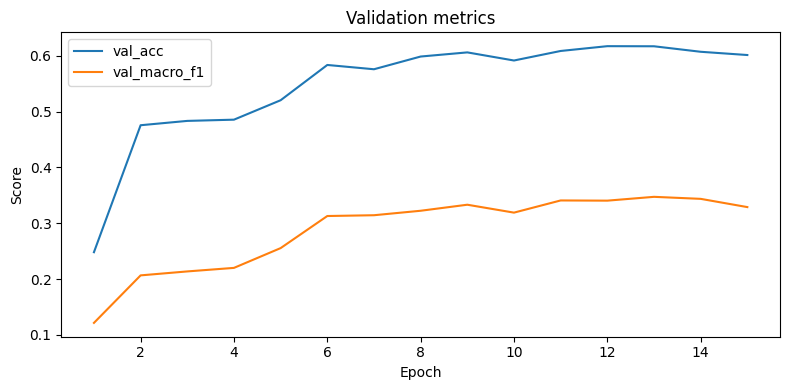

systems2024_arch1_1dcnn_seed_55 | epoch 01 | loss=0.4419 | val_acc=0.2353 | val_macro_f1=0.1169
systems2024_arch1_1dcnn_seed_55 | epoch 02 | loss=0.2991 | val_acc=0.2398 | val_macro_f1=0.1155
systems2024_arch1_1dcnn_seed_55 | epoch 03 | loss=0.2729 | val_acc=0.2433 | val_macro_f1=0.1196
systems2024_arch1_1dcnn_seed_55 | epoch 04 | loss=0.2493 | val_acc=0.5281 | val_macro_f1=0.2595
systems2024_arch1_1dcnn_seed_55 | epoch 05 | loss=0.2336 | val_acc=0.5432 | val_macro_f1=0.2766
systems2024_arch1_1dcnn_seed_55 | epoch 06 | loss=0.2236 | val_acc=0.5493 | val_macro_f1=0.2804
systems2024_arch1_1dcnn_seed_55 | epoch 07 | loss=0.2160 | val_acc=0.5488 | val_macro_f1=0.2849
systems2024_arch1_1dcnn_seed_55 | epoch 08 | loss=0.2060 | val_acc=0.5601 | val_macro_f1=0.2946
systems2024_arch1_1dcnn_seed_55 | epoch 09 | loss=0.1968 | val_acc=0.5767 | val_macro_f1=0.3057
systems2024_arch1_1dcnn_seed_55 | epoch 10 | loss=0.1965 | val_acc=0.5868 | val_macro_f1=0.3138
systems2024_arch1_1dcnn_seed_55 | epoch 

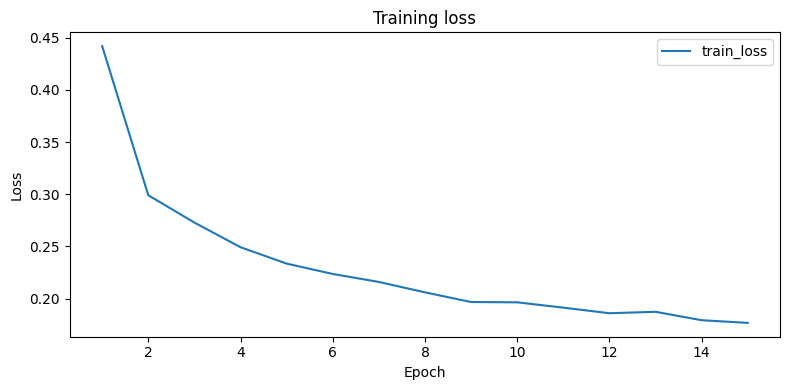

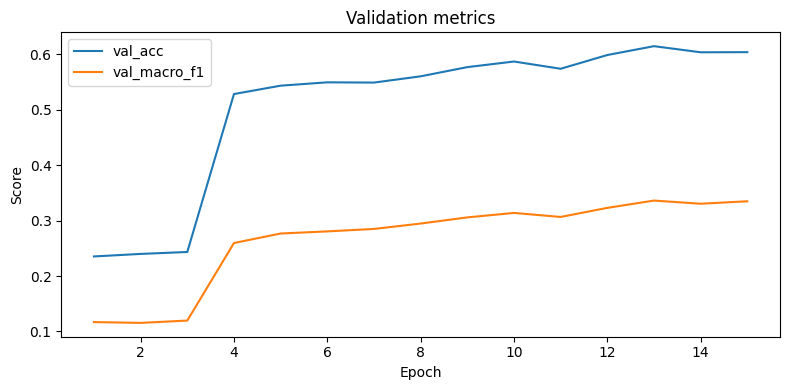

UNSW summary


,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,macro_recall_mean,macro_recall_std,weighted_f1_mean,weighted_f1_std
0,systems2024_arch1_1dcnn,0.561458,0.009155,0.286563,0.005174,0.507527,0.002232,0.642713,0.007392


Synthetic transfer summary


,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,macro_recall_mean,macro_recall_std,weighted_f1_mean,weighted_f1_std,rows_kept_mean,rows_total_mean
0,systems2024_arch1_1dcnn,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,450.0,450.0


Running: systems2024_arch2_1dcnn | task: multiclass


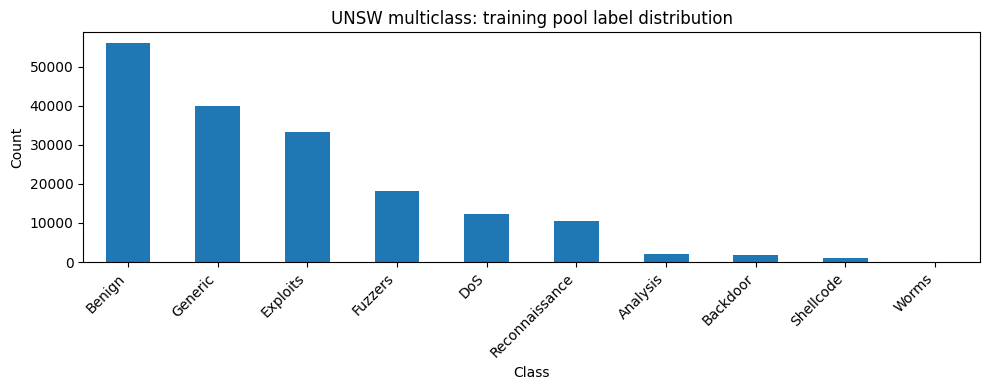

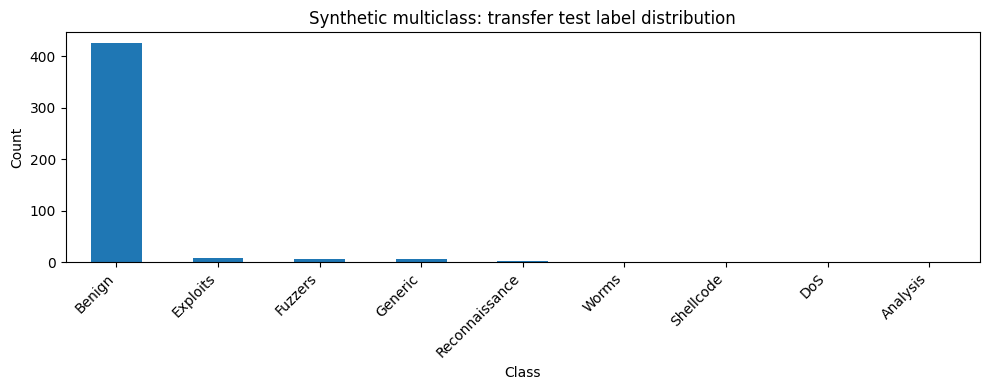

systems2024_arch2_1dcnn_seed_11 | epoch 01 | loss=0.4335 | val_acc=0.2775 | val_macro_f1=0.1151
systems2024_arch2_1dcnn_seed_11 | epoch 02 | loss=0.2660 | val_acc=0.5045 | val_macro_f1=0.2428
systems2024_arch2_1dcnn_seed_11 | epoch 03 | loss=0.2409 | val_acc=0.5111 | val_macro_f1=0.2550
systems2024_arch2_1dcnn_seed_11 | epoch 04 | loss=0.2194 | val_acc=0.5874 | val_macro_f1=0.3177
systems2024_arch2_1dcnn_seed_11 | epoch 05 | loss=0.2041 | val_acc=0.5824 | val_macro_f1=0.3121
systems2024_arch2_1dcnn_seed_11 | epoch 06 | loss=0.1931 | val_acc=0.5888 | val_macro_f1=0.3218
systems2024_arch2_1dcnn_seed_11 | epoch 07 | loss=0.1991 | val_acc=0.5901 | val_macro_f1=0.3203
systems2024_arch2_1dcnn_seed_11 | epoch 08 | loss=0.1898 | val_acc=0.6088 | val_macro_f1=0.3405
systems2024_arch2_1dcnn_seed_11 | epoch 09 | loss=0.1883 | val_acc=0.6129 | val_macro_f1=0.3430
systems2024_arch2_1dcnn_seed_11 | epoch 10 | loss=0.1799 | val_acc=0.6183 | val_macro_f1=0.3481
systems2024_arch2_1dcnn_seed_11 | epoch 

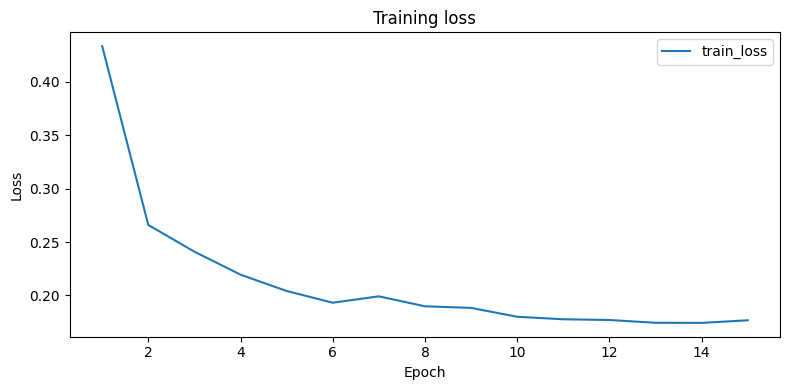

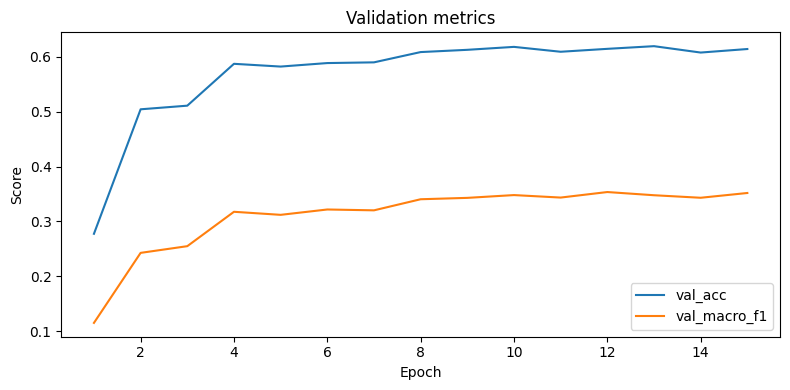

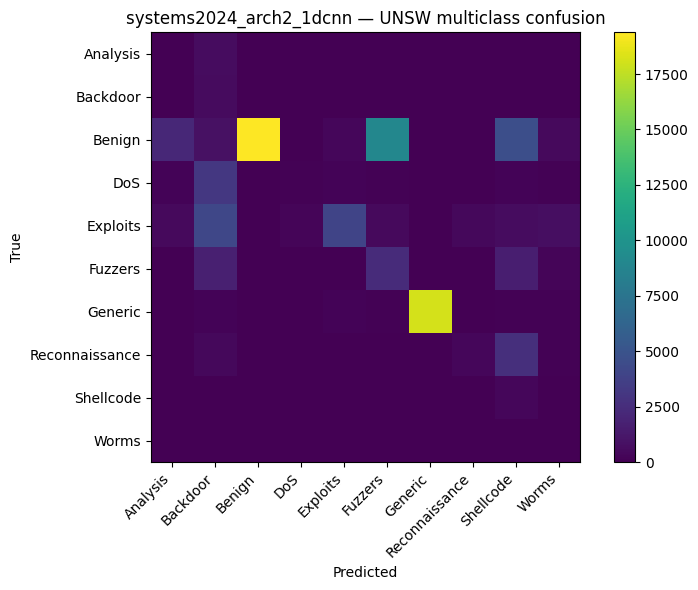

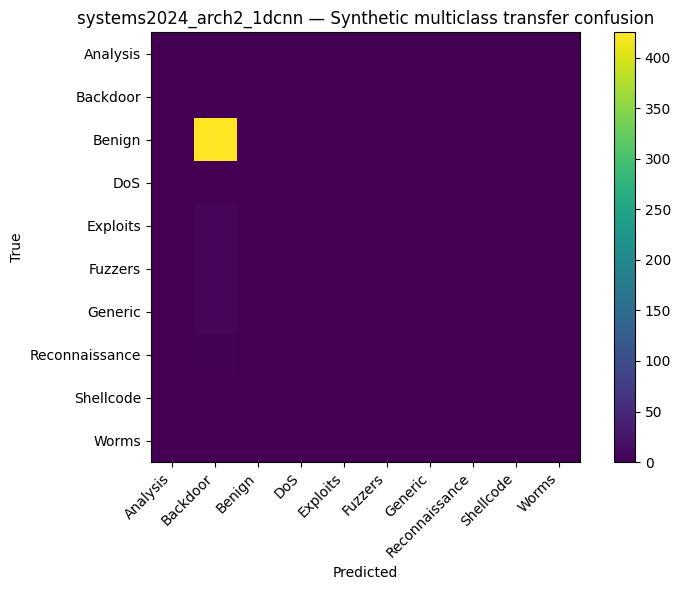

systems2024_arch2_1dcnn_seed_22 | epoch 01 | loss=0.4643 | val_acc=0.0177 | val_macro_f1=0.0158
systems2024_arch2_1dcnn_seed_22 | epoch 02 | loss=0.2731 | val_acc=0.4795 | val_macro_f1=0.2138
systems2024_arch2_1dcnn_seed_22 | epoch 03 | loss=0.2418 | val_acc=0.5184 | val_macro_f1=0.2557
systems2024_arch2_1dcnn_seed_22 | epoch 04 | loss=0.2261 | val_acc=0.5663 | val_macro_f1=0.2980
systems2024_arch2_1dcnn_seed_22 | epoch 05 | loss=0.2099 | val_acc=0.5847 | val_macro_f1=0.3110
systems2024_arch2_1dcnn_seed_22 | epoch 06 | loss=0.2026 | val_acc=0.5785 | val_macro_f1=0.3125
systems2024_arch2_1dcnn_seed_22 | epoch 07 | loss=0.1918 | val_acc=0.5949 | val_macro_f1=0.3266
systems2024_arch2_1dcnn_seed_22 | epoch 08 | loss=0.1878 | val_acc=0.6120 | val_macro_f1=0.3373
systems2024_arch2_1dcnn_seed_22 | epoch 09 | loss=0.1822 | val_acc=0.6109 | val_macro_f1=0.3484
systems2024_arch2_1dcnn_seed_22 | epoch 10 | loss=0.1855 | val_acc=0.6079 | val_macro_f1=0.3363
systems2024_arch2_1dcnn_seed_22 | epoch 

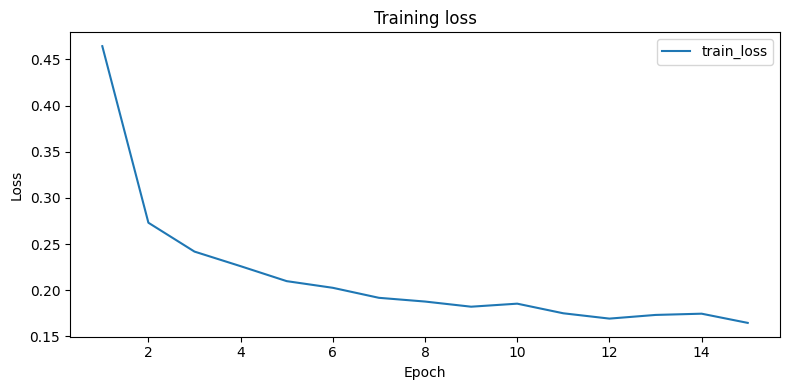

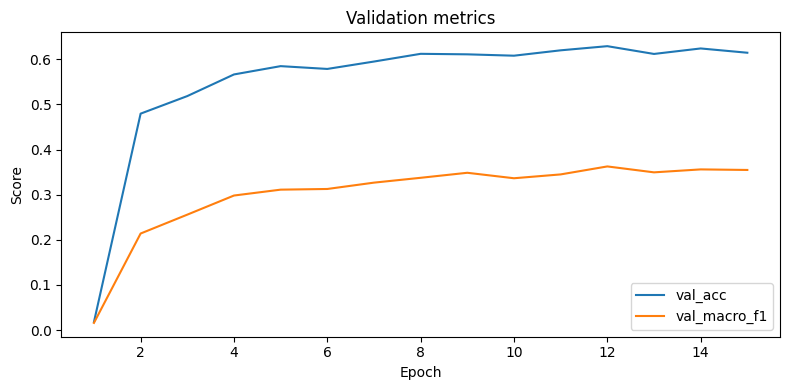

systems2024_arch2_1dcnn_seed_33 | epoch 01 | loss=0.4775 | val_acc=0.2385 | val_macro_f1=0.1035
systems2024_arch2_1dcnn_seed_33 | epoch 02 | loss=0.2757 | val_acc=0.2568 | val_macro_f1=0.1174
systems2024_arch2_1dcnn_seed_33 | epoch 03 | loss=0.2518 | val_acc=0.3880 | val_macro_f1=0.1785
systems2024_arch2_1dcnn_seed_33 | epoch 04 | loss=0.2314 | val_acc=0.5134 | val_macro_f1=0.2485
systems2024_arch2_1dcnn_seed_33 | epoch 05 | loss=0.2305 | val_acc=0.5339 | val_macro_f1=0.2690
systems2024_arch2_1dcnn_seed_33 | epoch 06 | loss=0.2095 | val_acc=0.5801 | val_macro_f1=0.3066
systems2024_arch2_1dcnn_seed_33 | epoch 07 | loss=0.2105 | val_acc=0.5762 | val_macro_f1=0.3025
systems2024_arch2_1dcnn_seed_33 | epoch 08 | loss=0.1944 | val_acc=0.6149 | val_macro_f1=0.3346
systems2024_arch2_1dcnn_seed_33 | epoch 09 | loss=0.2013 | val_acc=0.5985 | val_macro_f1=0.3238
systems2024_arch2_1dcnn_seed_33 | epoch 10 | loss=0.1919 | val_acc=0.6102 | val_macro_f1=0.3330
systems2024_arch2_1dcnn_seed_33 | epoch 

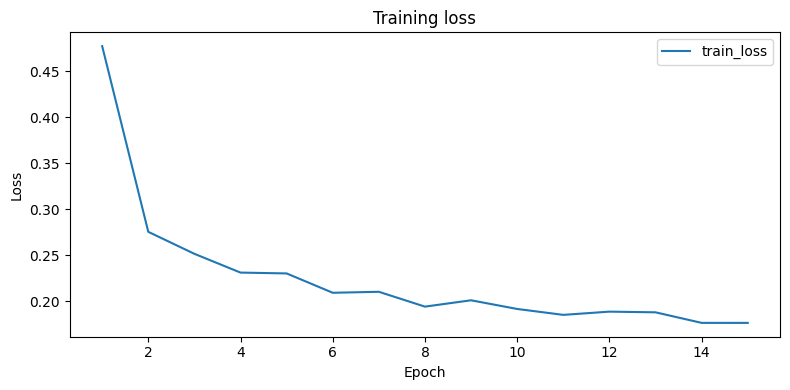

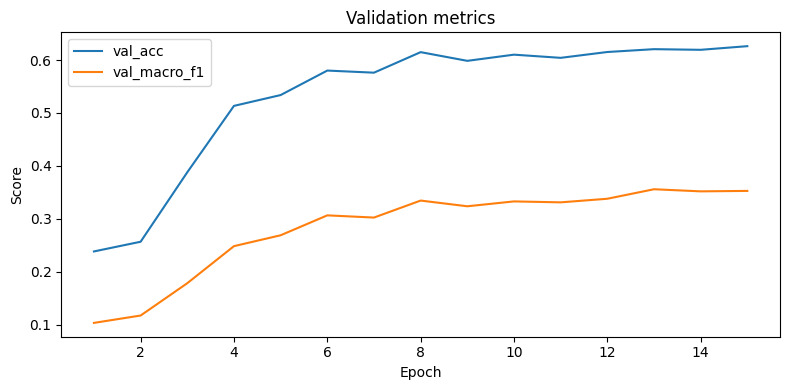

systems2024_arch2_1dcnn_seed_44 | epoch 01 | loss=0.4387 | val_acc=0.0180 | val_macro_f1=0.0116
systems2024_arch2_1dcnn_seed_44 | epoch 02 | loss=0.2842 | val_acc=0.3596 | val_macro_f1=0.1538
systems2024_arch2_1dcnn_seed_44 | epoch 03 | loss=0.2527 | val_acc=0.5022 | val_macro_f1=0.2261
systems2024_arch2_1dcnn_seed_44 | epoch 04 | loss=0.2352 | val_acc=0.5406 | val_macro_f1=0.2695
systems2024_arch2_1dcnn_seed_44 | epoch 05 | loss=0.2209 | val_acc=0.5759 | val_macro_f1=0.3047
systems2024_arch2_1dcnn_seed_44 | epoch 06 | loss=0.2063 | val_acc=0.5803 | val_macro_f1=0.3081
systems2024_arch2_1dcnn_seed_44 | epoch 07 | loss=0.2110 | val_acc=0.5805 | val_macro_f1=0.3094
systems2024_arch2_1dcnn_seed_44 | epoch 08 | loss=0.2032 | val_acc=0.5928 | val_macro_f1=0.3207
systems2024_arch2_1dcnn_seed_44 | epoch 09 | loss=0.1892 | val_acc=0.6056 | val_macro_f1=0.3311
systems2024_arch2_1dcnn_seed_44 | epoch 10 | loss=0.1853 | val_acc=0.6243 | val_macro_f1=0.3442
systems2024_arch2_1dcnn_seed_44 | epoch 

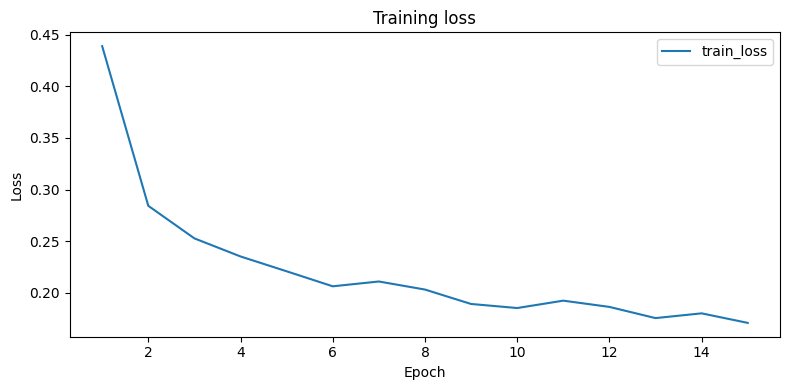

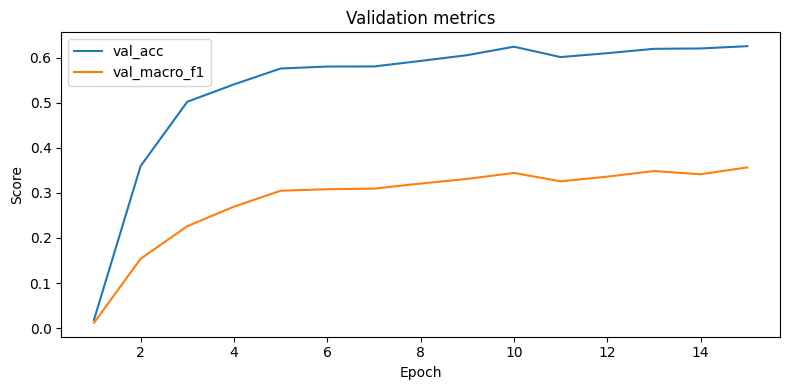

systems2024_arch2_1dcnn_seed_55 | epoch 01 | loss=0.4354 | val_acc=0.2388 | val_macro_f1=0.1066
systems2024_arch2_1dcnn_seed_55 | epoch 02 | loss=0.2699 | val_acc=0.4849 | val_macro_f1=0.2074
systems2024_arch2_1dcnn_seed_55 | epoch 03 | loss=0.2457 | val_acc=0.5076 | val_macro_f1=0.2364
systems2024_arch2_1dcnn_seed_55 | epoch 04 | loss=0.2243 | val_acc=0.5576 | val_macro_f1=0.2834
systems2024_arch2_1dcnn_seed_55 | epoch 05 | loss=0.2129 | val_acc=0.5765 | val_macro_f1=0.3047
systems2024_arch2_1dcnn_seed_55 | epoch 06 | loss=0.2025 | val_acc=0.5861 | val_macro_f1=0.3112
systems2024_arch2_1dcnn_seed_55 | epoch 07 | loss=0.1963 | val_acc=0.6007 | val_macro_f1=0.3227
systems2024_arch2_1dcnn_seed_55 | epoch 08 | loss=0.1870 | val_acc=0.6154 | val_macro_f1=0.3334
systems2024_arch2_1dcnn_seed_55 | epoch 09 | loss=0.1845 | val_acc=0.6211 | val_macro_f1=0.3458
systems2024_arch2_1dcnn_seed_55 | epoch 10 | loss=0.1889 | val_acc=0.6046 | val_macro_f1=0.3329
systems2024_arch2_1dcnn_seed_55 | epoch 

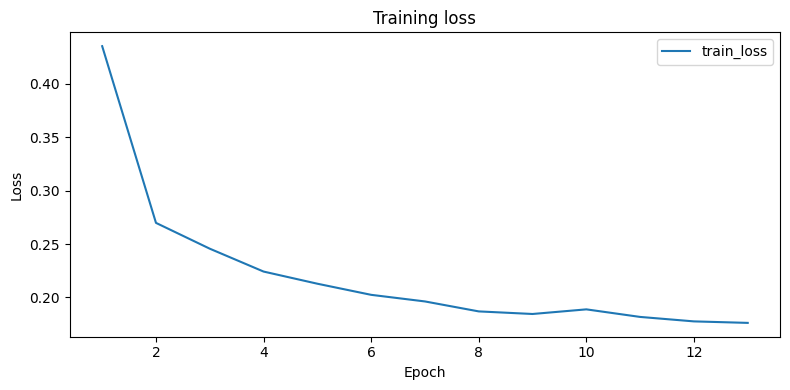

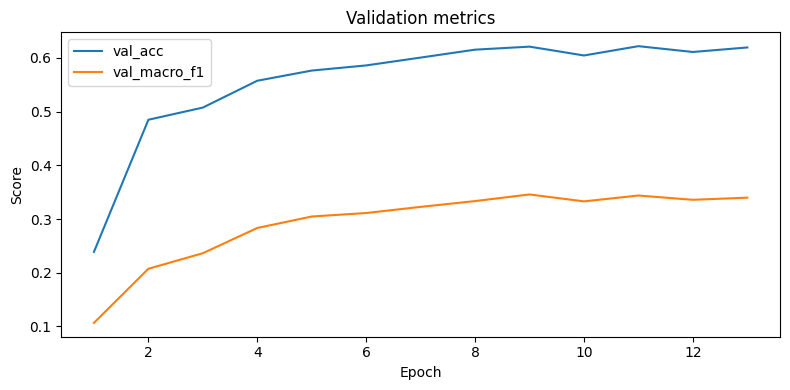

UNSW summary


,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,macro_recall_mean,macro_recall_std,weighted_f1_mean,weighted_f1_std
0,systems2024_arch2_1dcnn,0.561927,0.011628,0.285573,0.005238,0.514131,0.008051,0.640514,0.009681


Synthetic transfer summary


,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,macro_recall_mean,macro_recall_std,weighted_f1_mean,weighted_f1_std,rows_kept_mean,rows_total_mean
0,systems2024_arch2_1dcnn,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,450.0,450.0


Running: noever2021_mobilenetv2_image | task: multiclass


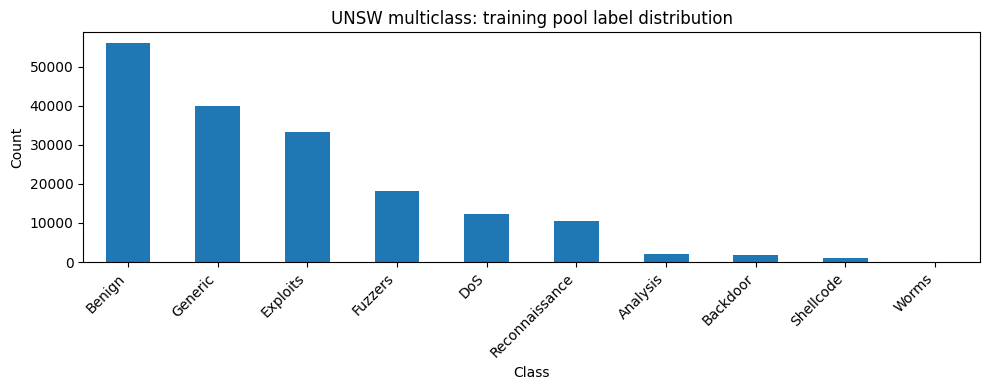

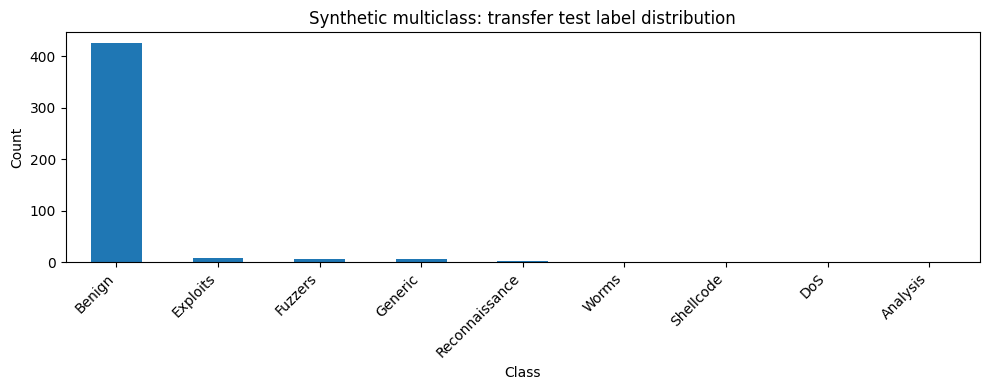

noever2021_mobilenetv2_image_seed_11 | epoch 01 | loss=0.4754 | val_acc=0.2874 | val_macro_f1=0.1556
noever2021_mobilenetv2_image_seed_11 | epoch 02 | loss=0.3656 | val_acc=0.4968 | val_macro_f1=0.2539
noever2021_mobilenetv2_image_seed_11 | epoch 03 | loss=0.3237 | val_acc=0.5792 | val_macro_f1=0.3319
noever2021_mobilenetv2_image_seed_11 | epoch 04 | loss=0.3076 | val_acc=0.5664 | val_macro_f1=0.3203
noever2021_mobilenetv2_image_seed_11 | epoch 05 | loss=0.2940 | val_acc=0.5727 | val_macro_f1=0.3250
noever2021_mobilenetv2_image_seed_11 | epoch 06 | loss=0.2891 | val_acc=0.6306 | val_macro_f1=0.4116
noever2021_mobilenetv2_image_seed_11 | epoch 07 | loss=0.2678 | val_acc=0.6035 | val_macro_f1=0.3696
noever2021_mobilenetv2_image_seed_11 | epoch 08 | loss=0.2767 | val_acc=0.5829 | val_macro_f1=0.3527
noever2021_mobilenetv2_image_seed_11 | epoch 09 | loss=0.2640 | val_acc=0.5610 | val_macro_f1=0.3247
noever2021_mobilenetv2_image_seed_11 | epoch 10 | loss=0.2648 | val_acc=0.6302 | val_macro_

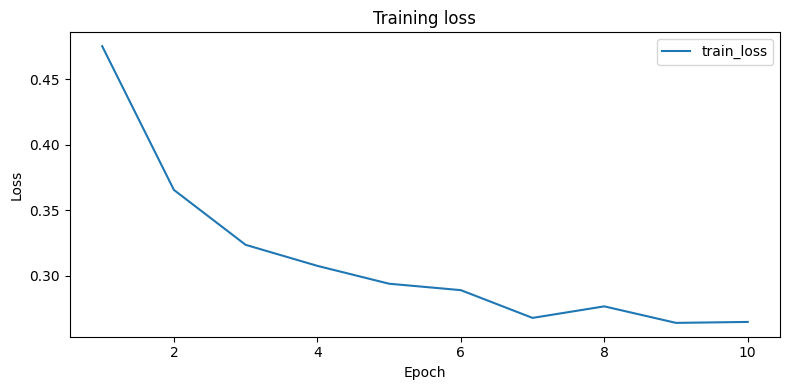

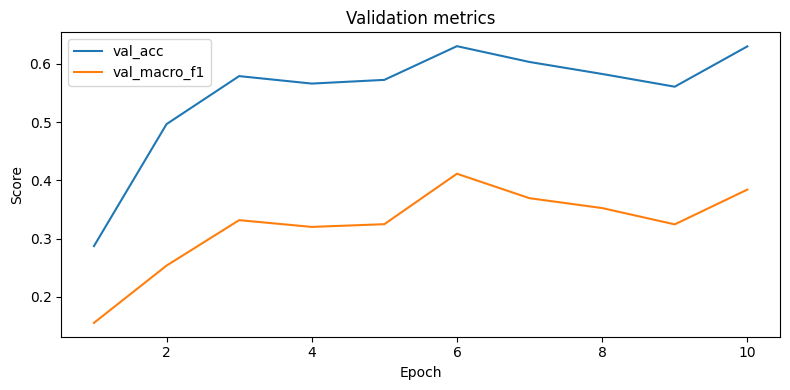

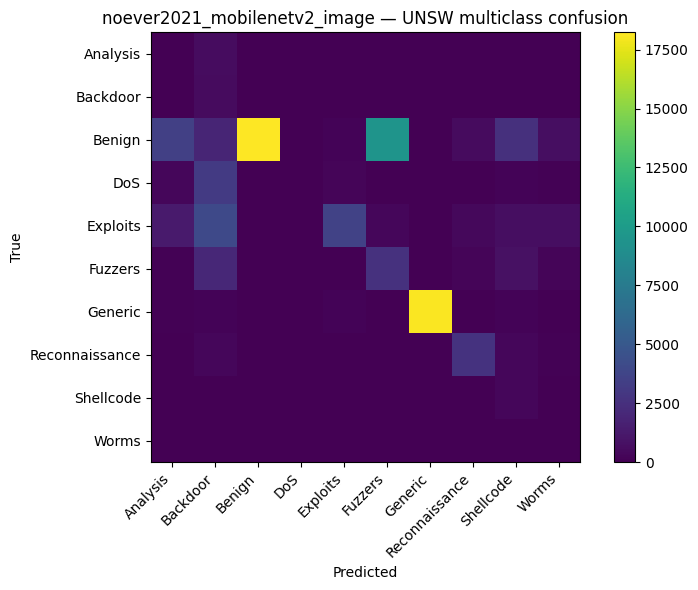

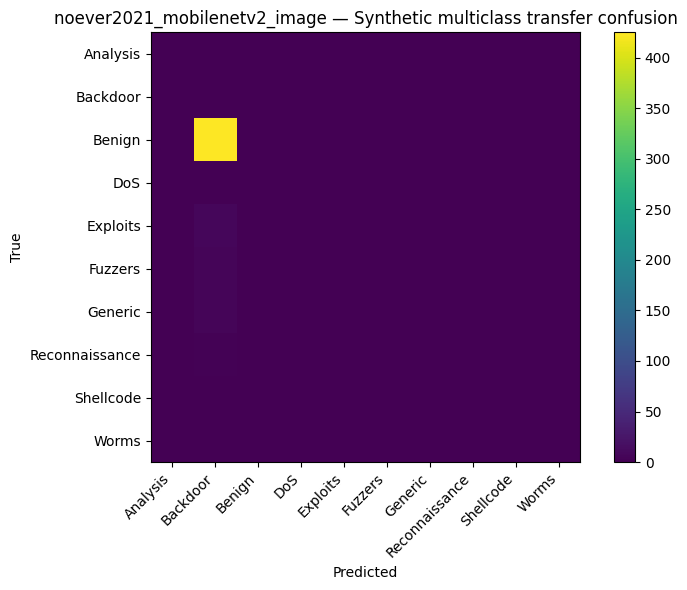

noever2021_mobilenetv2_image_seed_22 | epoch 01 | loss=0.4653 | val_acc=0.5203 | val_macro_f1=0.2622
noever2021_mobilenetv2_image_seed_22 | epoch 02 | loss=0.3640 | val_acc=0.5397 | val_macro_f1=0.2854
noever2021_mobilenetv2_image_seed_22 | epoch 03 | loss=0.3286 | val_acc=0.5832 | val_macro_f1=0.3067
noever2021_mobilenetv2_image_seed_22 | epoch 04 | loss=0.3052 | val_acc=0.4662 | val_macro_f1=0.2645
noever2021_mobilenetv2_image_seed_22 | epoch 05 | loss=0.2897 | val_acc=0.6211 | val_macro_f1=0.3841
noever2021_mobilenetv2_image_seed_22 | epoch 06 | loss=0.2885 | val_acc=0.6115 | val_macro_f1=0.3445
noever2021_mobilenetv2_image_seed_22 | epoch 07 | loss=0.2874 | val_acc=0.6399 | val_macro_f1=0.4217
noever2021_mobilenetv2_image_seed_22 | epoch 08 | loss=0.2718 | val_acc=0.6209 | val_macro_f1=0.3782
noever2021_mobilenetv2_image_seed_22 | epoch 09 | loss=0.2651 | val_acc=0.5844 | val_macro_f1=0.3288
noever2021_mobilenetv2_image_seed_22 | epoch 10 | loss=0.2599 | val_acc=0.6363 | val_macro_

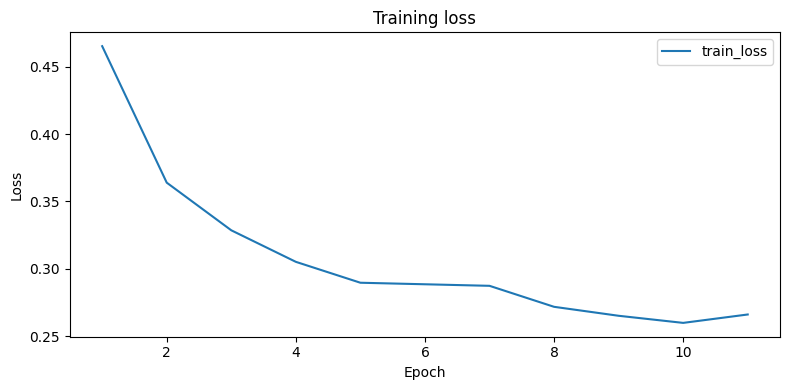

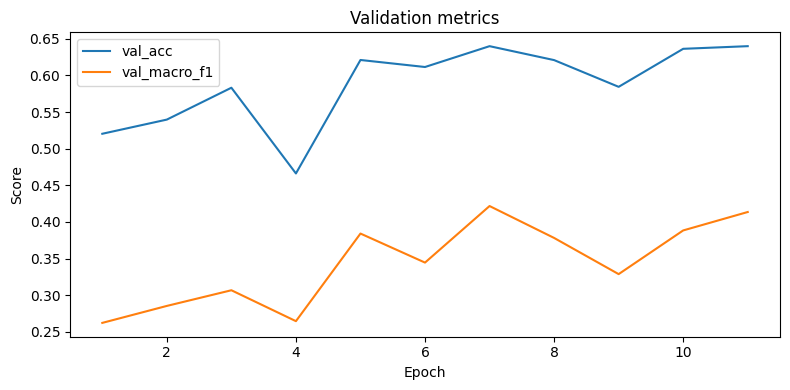

noever2021_mobilenetv2_image_seed_33 | epoch 01 | loss=0.4599 | val_acc=0.3001 | val_macro_f1=0.1662
noever2021_mobilenetv2_image_seed_33 | epoch 02 | loss=0.3667 | val_acc=0.5030 | val_macro_f1=0.2564
noever2021_mobilenetv2_image_seed_33 | epoch 03 | loss=0.3096 | val_acc=0.5467 | val_macro_f1=0.3123
noever2021_mobilenetv2_image_seed_33 | epoch 04 | loss=0.2993 | val_acc=0.5951 | val_macro_f1=0.3287
noever2021_mobilenetv2_image_seed_33 | epoch 05 | loss=0.2878 | val_acc=0.6266 | val_macro_f1=0.3898
noever2021_mobilenetv2_image_seed_33 | epoch 06 | loss=0.2745 | val_acc=0.5717 | val_macro_f1=0.3342
noever2021_mobilenetv2_image_seed_33 | epoch 07 | loss=0.2645 | val_acc=0.5854 | val_macro_f1=0.3529
noever2021_mobilenetv2_image_seed_33 | epoch 08 | loss=0.2635 | val_acc=0.6291 | val_macro_f1=0.3800
noever2021_mobilenetv2_image_seed_33 | epoch 09 | loss=0.2662 | val_acc=0.6552 | val_macro_f1=0.4158
noever2021_mobilenetv2_image_seed_33 | epoch 10 | loss=0.2638 | val_acc=0.6522 | val_macro_

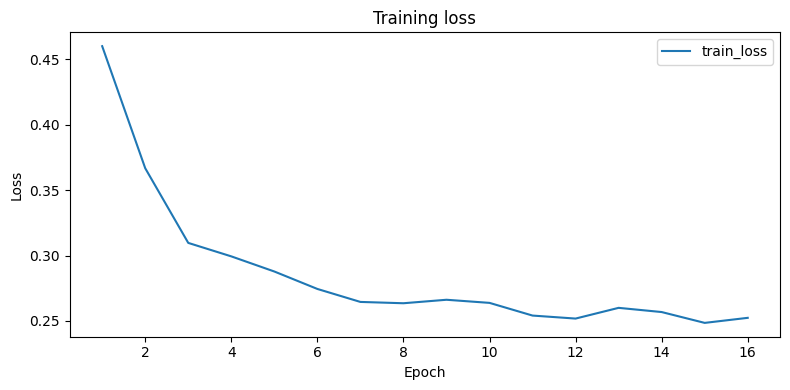

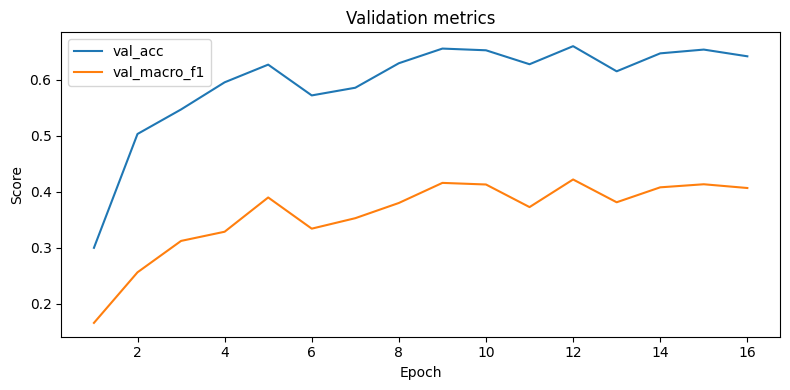

noever2021_mobilenetv2_image_seed_44 | epoch 01 | loss=0.4611 | val_acc=0.4100 | val_macro_f1=0.1831
noever2021_mobilenetv2_image_seed_44 | epoch 02 | loss=0.3623 | val_acc=0.4500 | val_macro_f1=0.2440
noever2021_mobilenetv2_image_seed_44 | epoch 03 | loss=0.3337 | val_acc=0.5150 | val_macro_f1=0.2819
noever2021_mobilenetv2_image_seed_44 | epoch 04 | loss=0.3112 | val_acc=0.5792 | val_macro_f1=0.3231
noever2021_mobilenetv2_image_seed_44 | epoch 05 | loss=0.2999 | val_acc=0.5736 | val_macro_f1=0.3294
noever2021_mobilenetv2_image_seed_44 | epoch 06 | loss=0.2861 | val_acc=0.6008 | val_macro_f1=0.3420
noever2021_mobilenetv2_image_seed_44 | epoch 07 | loss=0.2752 | val_acc=0.6086 | val_macro_f1=0.3784
noever2021_mobilenetv2_image_seed_44 | epoch 08 | loss=0.2690 | val_acc=0.5637 | val_macro_f1=0.3073
noever2021_mobilenetv2_image_seed_44 | epoch 09 | loss=0.2673 | val_acc=0.6148 | val_macro_f1=0.3632
noever2021_mobilenetv2_image_seed_44 | epoch 10 | loss=0.2672 | val_acc=0.6199 | val_macro_

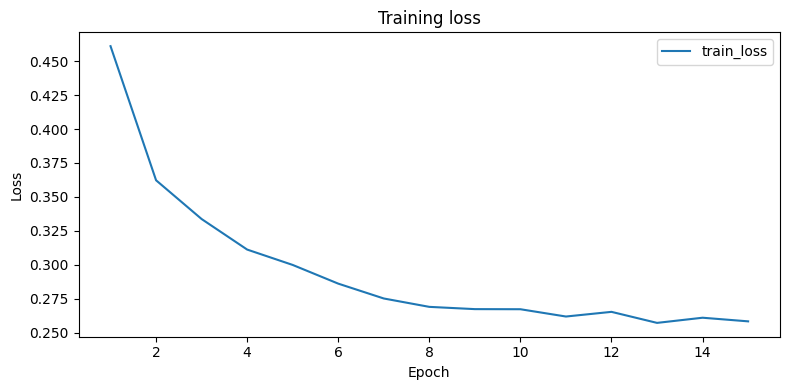

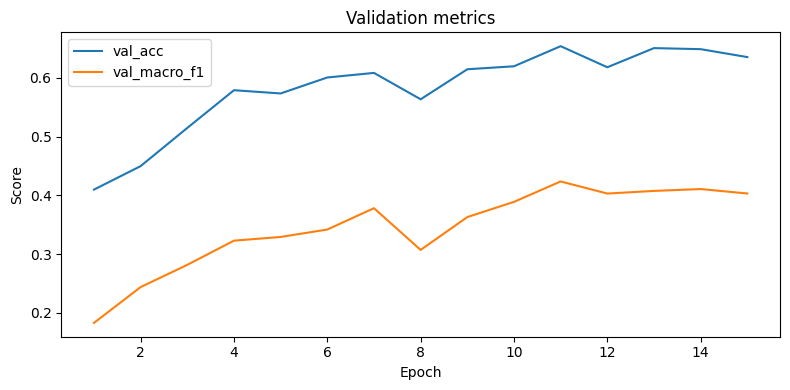

noever2021_mobilenetv2_image_seed_55 | epoch 01 | loss=0.4629 | val_acc=0.4551 | val_macro_f1=0.2057
noever2021_mobilenetv2_image_seed_55 | epoch 02 | loss=0.3699 | val_acc=0.5270 | val_macro_f1=0.2627
noever2021_mobilenetv2_image_seed_55 | epoch 03 | loss=0.3333 | val_acc=0.5703 | val_macro_f1=0.3134
noever2021_mobilenetv2_image_seed_55 | epoch 04 | loss=0.3105 | val_acc=0.5723 | val_macro_f1=0.3007
noever2021_mobilenetv2_image_seed_55 | epoch 05 | loss=0.2982 | val_acc=0.6036 | val_macro_f1=0.3467
noever2021_mobilenetv2_image_seed_55 | epoch 06 | loss=0.2831 | val_acc=0.6132 | val_macro_f1=0.3794
noever2021_mobilenetv2_image_seed_55 | epoch 07 | loss=0.2825 | val_acc=0.6149 | val_macro_f1=0.3802
noever2021_mobilenetv2_image_seed_55 | epoch 08 | loss=0.2753 | val_acc=0.6308 | val_macro_f1=0.3902
noever2021_mobilenetv2_image_seed_55 | epoch 09 | loss=0.2706 | val_acc=0.6496 | val_macro_f1=0.4010
noever2021_mobilenetv2_image_seed_55 | epoch 10 | loss=0.2723 | val_acc=0.6041 | val_macro_

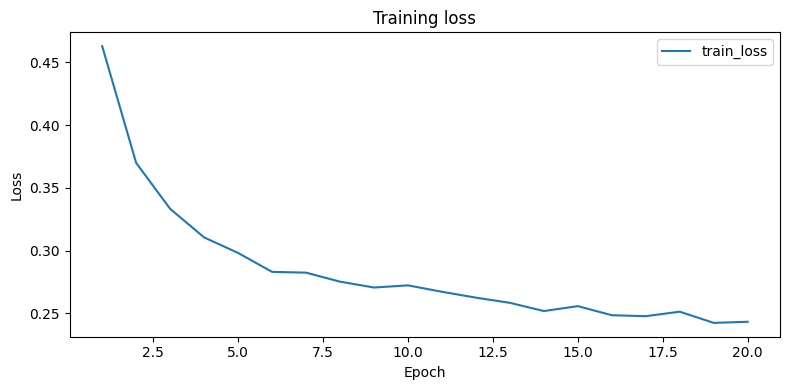

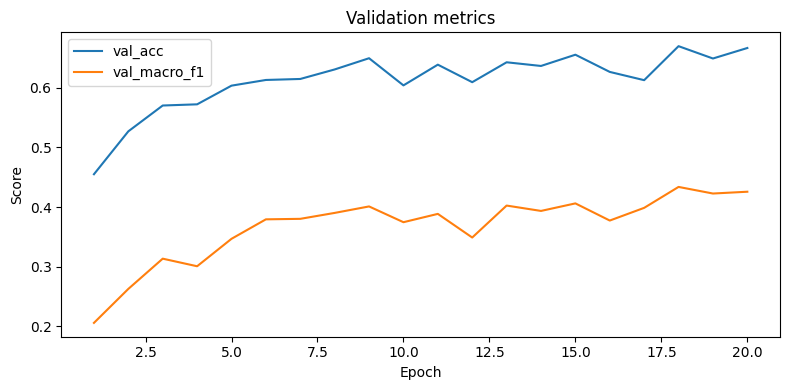

UNSW summary


,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,macro_recall_mean,macro_recall_std,weighted_f1_mean,weighted_f1_std
0,noever2021_mobilenetv2_image,0.56757,0.012319,0.344849,0.011751,0.586486,0.011802,0.642261,0.010437


Synthetic transfer summary


,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,macro_recall_mean,macro_recall_std,weighted_f1_mean,weighted_f1_std,rows_kept_mean,rows_total_mean
0,noever2021_mobilenetv2_image,0.002667,0.004818,0.000528,0.000953,0.04,0.054772,0.000051,0.000108,450.0,450.0


In [9]:
# ============================================================
# 8) Run all models
# ============================================================
results = {}

for task in ["binary", "multiclass"]:
    results[task] = {}
    for model_name in MODEL_NAMES:
        print("=" * 80)
        print("Running:", model_name, "| task:", task)
        unsw_runs_df, unsw_summary, syn_runs_df, syn_summary = run_model_for_task(model_name, task)
        results[task][model_name] = {
            "unsw_runs": unsw_runs_df,
            "unsw_summary": unsw_summary,
            "synthetic_runs": syn_runs_df,
            "synthetic_summary": syn_summary,
        }
        print("UNSW summary")
        display(unsw_summary)
        print("Synthetic transfer summary")
        display(syn_summary)

## 9) Build combined comparison tables

### 1. UNSW benchmark performance
This tells us how well the literature CNN method works **in-domain** on the original benchmark.

### 2. Synthetic transfer performance
This tells us how much of that learned behaviour survives when the model is moved to the synthetic IPv6 dataset.

### 3. Drop analysis
This tells us how much performance is lost between:
- **UNSW benchmark test**
- **Synthetic transfer test**

A large drop usually points to one or more of these:
- domain shift
- label or class-prior mismatch
- different feature meaning across datasets
- different image-construction logic
- paper preprocessing not being matched exactly

In [10]:
# ============================================================
# 9) Combined comparison tables
# ============================================================
unsw_rows = []
syn_rows = []
drop_rows = []
paper_rows = []

for task in ["binary", "multiclass"]:
    for model_name in MODEL_NAMES:
        us = results[task][model_name]["unsw_summary"].copy()
        sy = results[task][model_name]["synthetic_summary"].copy()

        us["task"] = task
        us["model"] = model_name
        sy["task"] = task
        sy["model"] = model_name

        unsw_rows.append(us)
        syn_rows.append(sy)

        if task == "binary":
            drop_rows.append({
                "task": task,
                "model": model_name,
                "unsw_accuracy_mean": float(us.iloc[0]["accuracy_mean"]),
                "synthetic_accuracy_mean": float(sy.iloc[0]["accuracy_mean"]),
                "accuracy_drop": float(us.iloc[0]["accuracy_mean"] - sy.iloc[0]["accuracy_mean"]),
                "unsw_f1_mean": float(us.iloc[0]["f1_mean"]),
                "synthetic_f1_mean": float(sy.iloc[0]["f1_mean"]),
                "f1_drop": float(us.iloc[0]["f1_mean"] - sy.iloc[0]["f1_mean"]),
            })
        else:
            drop_rows.append({
                "task": task,
                "model": model_name,
                "unsw_accuracy_mean": float(us.iloc[0]["accuracy_mean"]),
                "synthetic_accuracy_mean": float(sy.iloc[0]["accuracy_mean"]),
                "accuracy_drop": float(us.iloc[0]["accuracy_mean"] - sy.iloc[0]["accuracy_mean"]),
                "unsw_macro_f1_mean": float(us.iloc[0]["macro_f1_mean"]),
                "synthetic_macro_f1_mean": float(sy.iloc[0]["macro_f1_mean"]),
                "macro_f1_drop": float(us.iloc[0]["macro_f1_mean"] - sy.iloc[0]["macro_f1_mean"]),
            })

        p = OUT_ROOT / "unsw" / task / model_name / "tables" / "paper_vs_reproduced.csv"
        if p.exists():
            paper_rows.append(pd.read_csv(p))

unsw_cmp = pd.concat(unsw_rows, ignore_index=True)
syn_cmp = pd.concat(syn_rows, ignore_index=True)
drop_df = pd.DataFrame(drop_rows)
paper_df = pd.concat(paper_rows, ignore_index=True) if len(paper_rows) > 0 else pd.DataFrame()

unsw_cmp.to_csv(OUT_ROOT / "combined" / "unsw_benchmark_cnn_comparison.csv", index=False)
syn_cmp.to_csv(OUT_ROOT / "combined" / "synthetic_transfer_cnn_comparison.csv", index=False)
drop_df.to_csv(OUT_ROOT / "combined" / "unsw_to_synthetic_drop_analysis.csv", index=False)
if not paper_df.empty:
    paper_df.to_csv(OUT_ROOT / "combined" / "paper_vs_reproduced_all.csv", index=False)

print("UNSW benchmark comparison")
display(unsw_cmp)

print("Synthetic transfer comparison")
display(syn_cmp)

print("Drop analysis")
display(drop_df)

if not paper_df.empty:
    print("Paper vs reproduced")
    display(paper_df)

UNSW benchmark comparison


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,task,macro_f1_mean,macro_f1_std,macro_recall_mean,macro_recall_std,weighted_f1_mean,weighted_f1_std
0,systems2024_arch1_1dcnn,0.847658,0.010214,0.787634,0.011792,0.990656,0.001378,0.877514,0.007163,binary,NaN,NaN,NaN,NaN,NaN,NaN
1,systems2024_arch2_1dcnn,0.852191,0.012212,0.793184,0.014935,0.990122,0.002473,0.880699,0.008343,binary,NaN,NaN,NaN,NaN,NaN,NaN
2,noever2021_mobilenetv2_image,0.857181,0.010616,0.800392,0.012819,0.987025,0.003883,0.883914,0.007679,binary,NaN,NaN,NaN,NaN,NaN,NaN
3,systems2024_arch1_1dcnn,0.561458,0.009155,NaN,NaN,NaN,NaN,NaN,NaN,multiclass,0.286563,0.005174,0.507527,0.002232,0.642713,0.007392
4,systems2024_arch2_1dcnn,0.561927,0.011628,NaN,NaN,NaN,NaN,NaN,NaN,multiclass,0.285573,0.005238,0.514131,0.008051,0.640514,0.009681
5,noever2021_mobilenetv2_image,0.567570,0.012319,NaN,NaN,NaN,NaN,NaN,NaN,multiclass,0.344849,0.011751,0.586486,0.011802,0.642261,0.010437


Synthetic transfer comparison


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,rows_kept_mean,rows_total_mean,task,macro_f1_mean,macro_f1_std,macro_recall_mean,macro_recall_std,weighted_f1_mean,weighted_f1_std
0,systems2024_arch1_1dcnn,0.055556,0.000000,0.055556,0.000000,1.0,0.000000,0.105263,0.000000,450.0,450.0,binary,NaN,NaN,NaN,NaN,NaN,NaN
1,systems2024_arch2_1dcnn,0.055556,0.000000,0.055556,0.000000,1.0,0.000000,0.105263,0.000000,450.0,450.0,binary,NaN,NaN,NaN,NaN,NaN,NaN
2,noever2021_mobilenetv2_image,0.588889,0.486864,0.022222,0.030429,0.4,0.547723,0.042105,0.057655,450.0,450.0,binary,NaN,NaN,NaN,NaN,NaN,NaN
3,systems2024_arch1_1dcnn,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,450.0,450.0,multiclass,0.000000,0.000000,0.00,0.000000,0.000000,0.000000
4,systems2024_arch2_1dcnn,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,450.0,450.0,multiclass,0.000000,0.000000,0.00,0.000000,0.000000,0.000000
5,noever2021_mobilenetv2_image,0.002667,0.004818,NaN,NaN,NaN,NaN,NaN,NaN,450.0,450.0,multiclass,0.000528,0.000953,0.04,0.054772,0.000051,0.000108


Drop analysis


,task,model,unsw_accuracy_mean,synthetic_accuracy_mean,accuracy_drop,unsw_f1_mean,synthetic_f1_mean,f1_drop,unsw_macro_f1_mean,synthetic_macro_f1_mean,macro_f1_drop
0,binary,systems2024_arch1_1dcnn,0.847658,0.055556,0.792103,0.877514,0.105263,0.772251,NaN,NaN,NaN
1,binary,systems2024_arch2_1dcnn,0.852191,0.055556,0.796636,0.880699,0.105263,0.775436,NaN,NaN,NaN
2,binary,noever2021_mobilenetv2_image,0.857181,0.588889,0.268292,0.883914,0.042105,0.841808,NaN,NaN,NaN
3,multiclass,systems2024_arch1_1dcnn,0.561458,0.000000,0.561458,NaN,NaN,NaN,0.286563,0.000000,0.286563
4,multiclass,systems2024_arch2_1dcnn,0.561927,0.000000,0.561927,NaN,NaN,NaN,0.285573,0.000000,0.285573
5,multiclass,noever2021_mobilenetv2_image,0.567570,0.002667,0.564904,NaN,NaN,NaN,0.344849,0.000528,0.344321


Paper vs reproduced


,model,task,reported_accuracy,reproduced_accuracy_mean,gap_reproduced_minus_reported,note
0,systems2024_arch1_1dcnn,binary,0.95,0.847658,-0.102342,approx. 95% binary accuracy
1,noever2021_mobilenetv2_image,binary,0.97,0.857181,-0.112819,97% binary accuracy
2,systems2024_arch1_1dcnn,multiclass,0.82,0.561458,-0.258542,82% multiclass accuracy
3,noever2021_mobilenetv2_image,multiclass,0.56,0.567570,0.007570,56% 10-class accuracy


## 10) Artefact dashboard

In [11]:
# ============================================================
# 10) Artefact dashboard
# ============================================================
def list_files(folder):
    return sorted([p.name for p in folder.glob("*")])

dashboard = {}

for root_name, root_path in {
    "unsw": OUT_ROOT / "unsw",
    "synthetic_transfer": OUT_ROOT / "synthetic_transfer",
}.items():
    dashboard[root_name] = {}
    for task in ["binary", "multiclass"]:
        dashboard[root_name][task] = {}
        for model_name in MODEL_NAMES:
            model_dir = root_path / task / model_name
            dashboard[root_name][task][model_name] = {
                "tables": list_files(model_dir / "tables"),
                "figures": list_files(model_dir / "figures"),
                "metrics": list_files(model_dir / "metrics"),
                "reports": list_files(model_dir / "reports"),
                "models": list_files(model_dir / "models"),
            }

dashboard["combined"] = list_files(OUT_ROOT / "combined")
save_json(dashboard, OUT_ROOT / "combined" / "artefact_dashboard.json")
dashboard

{'unsw': {'binary': {'systems2024_arch1_1dcnn': {'tables': ['all_runs.csv',
     'confusion_matrix_seed_11.csv',
     'paper_vs_reproduced.csv',
     'summary_mean_std.csv',
     'test_support_flags.csv'],
    'figures': ['confusion_seed_11.png',
     'label_distribution_pool.png',
     'systems2024_arch1_1dcnn_seed_11_pr_curve_val.png',
     'systems2024_arch1_1dcnn_seed_11_train_loss.png',
     'systems2024_arch1_1dcnn_seed_11_val_metrics.png',
     'systems2024_arch1_1dcnn_seed_22_pr_curve_val.png',
     'systems2024_arch1_1dcnn_seed_22_train_loss.png',
     'systems2024_arch1_1dcnn_seed_22_val_metrics.png',
     'systems2024_arch1_1dcnn_seed_33_pr_curve_val.png',
     'systems2024_arch1_1dcnn_seed_33_train_loss.png',
     'systems2024_arch1_1dcnn_seed_33_val_metrics.png',
     'systems2024_arch1_1dcnn_seed_44_pr_curve_val.png',
     'systems2024_arch1_1dcnn_seed_44_train_loss.png',
     'systems2024_arch1_1dcnn_seed_44_val_metrics.png',
     'systems2024_arch1_1dcnn_seed_55_pr_curv

## Why reproduced results differ from the original papers

Even if the benchmark CNN family is implemented in the same manner, the reproduced numbers can still differ from the paper numbers for several real reasons:

- the paper may not provide every small preprocessing or filtering step
- the current notebook uses one **shared benchmark pipeline** across all methods for fairness
- validation-based thresholding can lower headline binary accuracy compared with less strict evaluation
- the synthetic dataset is a **true transfer setting**, not just another UNSW split
- image-based methods are very sensitive to how tabular rows are converted into images
- due to computational liomitations the total number of epochs run might vary significantly

So the benchmark results can be claimed as:
- **paper-based reproduction inside our thesis pipeline**
- not as a guaranteed exact byte-for-byte duplication of the original paper environment

# End of notebook

After this notebook, the next step is to build **our own CNN models** and compare them against:
- classical baselines
- these paper-based benchmark CNNs
- transfer results on synthetic

## References and URLs

1. Mohammad et al., **Enhancing Intrusion Detection Systems Using a Deep Learning CNN Framework for Data Augmentation and Improved Classification**, Systems, 2024  
   https://www.mdpi.com/2079-8954/12/3/79

2. Noever and Noever, **Image Classifiers for Network Intrusions**, 2021  
   https://arxiv.org/abs/2103.07765

3. **UNSW-NB15 official dataset page**  
   https://research.unsw.edu.au/projects/unsw-nb15-dataset